<a href="https://colab.research.google.com/github/epm2wi/Causal-Inference-and-Discovery-in-Python/blob/main/Chapter_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
#!pip install dowhy econml causalml


In [78]:
from copy import deepcopy
import json
import time

import numpy as np
import pandas as pd
from scipy import stats

from sklearn.metrics import mean_absolute_percentage_error, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

import dowhy
from dowhy import CausalModel

from econml.metalearners import SLearner, XLearner, TLearner
from econml.dml import LinearDML, CausalForestDML, DML
from econml.dr import DRLearner, SparseLinearDRLearner

from sklearn.linear_model import LinearRegression, LogisticRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

from lightgbm import LGBMRegressor, LGBMClassifier

import networkx as nx

from tqdm import tqdm

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import graphviz

In [79]:
dowhy.__version__

'0.14'

In [80]:
COLORS = [
    '#00B0F0',
    '#FF0000',
    '#B0F000'
]

# Chapter 10



## Doubly Robust Methods: Let’s Get More!

In [81]:
def plot_effect(effect_true, effect_pred, figsize=(10, 7), ylim=(5000, 22000)):
    plt.figure(figsize=figsize)
    plt.scatter(effect_true, effect_pred, color=COLORS[0])
    plt.plot(np.sort(effect_true), np.sort(effect_true), color=COLORS[1], alpha=.7, label='Perfect model')
    plt.xlabel('$True\ effect$', fontsize=14, alpha=.5)
    plt.ylabel('$Predicted\ effect$', fontsize=14, alpha=.5)
    plt.ylim(ylim[0], ylim[1])
    plt.legend()
    plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:6: SyntaxWarning: invalid escape sequence '\ '
<>:5: SyntaxWarning: invalid escape sequence '\ '
<>:6: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_959/4097212502.py:5: SyntaxWarning: invalid escape sequence '\ '
  plt.xlabel('$True\ effect$', fontsize=14, alpha=.5)
/tmp/ipykernel_959/4097212502.py:6: SyntaxWarning: invalid escape sequence '\ '
  plt.ylabel('$Predicted\ effect$', fontsize=14, alpha=.5)


### Read the data

In [82]:
# Train set
earnings_interaction = pd.read_csv(r'https://raw.githubusercontent.com/PacktPublishing/Causal-Inference-and-Discovery-in-Python/refs/heads/main/data/ml_earnings_interaction_train.csv')

# Test set
earnings_interaction_all_true = pd.read_csv(r'https://raw.githubusercontent.com/PacktPublishing/Causal-Inference-and-Discovery-in-Python/refs/heads/main/data/ml_earnings_interaction_test.csv')

In [83]:
earnings_interaction_train,earnings_interaction_test = train_test_split(earnings_interaction)

In [84]:
# Train
earnings_interaction_train.head()

,age,python_proficiency,took_a_course,earnings
4111,28,0.832521,False,142704.0
982,32,0.691965,False,158505.0
1804,23,0.636235,False,123772.0
335,19,0.592820,False,111990.0
4575,25,0.722714,False,131841.0


In [85]:
# Test
earnings_interaction_test.head()

,age,python_proficiency,took_a_course,earnings
181,30,0.632877,False,148084.0
3505,21,0.243501,True,128417.0
2578,20,0.941272,False,113552.0
3204,28,0.862661,True,157552.0
4154,32,0.126398,False,157579.0


### Define the graph

In [86]:
# Construct the graph (the graph is constant for all iterations)
nodes = ['took_a_course', 'python_proficiency', 'earnings', 'age']
edges = [
    ('took_a_course', 'earnings'),
    ('age', 'took_a_course'),
    ('age', 'earnings'),
    ('python_proficiency', 'earnings')
]

# Generate the GML graph
gml_string = 'graph [directed 1\n'

for node in nodes:
    gml_string += f'\tnode [id "{node}" label "{node}"]\n'

for edge in edges:
    gml_string += f'\tedge [source "{edge[0]}" target "{edge[1]}"]\n'

gml_string += ']'

In [87]:
# Instantiate the CausalModel
model = CausalModel(
    data=earnings_interaction_train,
    treatment='took_a_course',
    outcome='earnings',
    effect_modifiers='python_proficiency',
    graph=gml_string
)

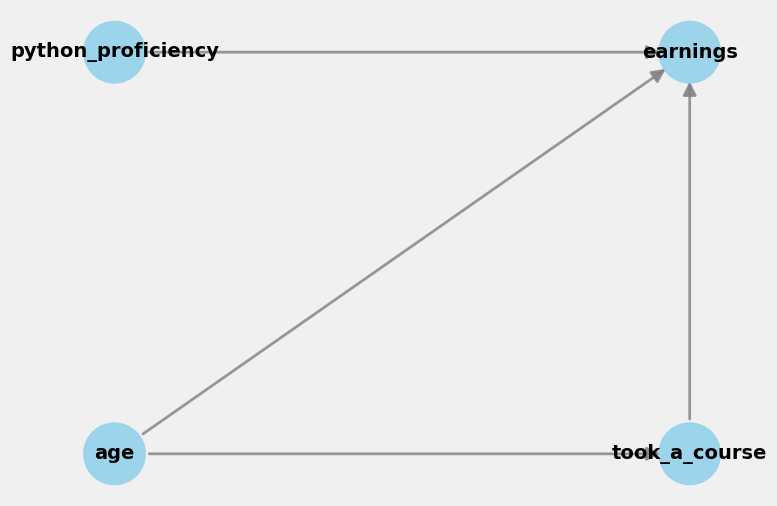

In [88]:
model.view_model()

### Get the estimand

In [89]:
# Get the estimand
estimand = model.identify_effect()

print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                         
────────────────(E[earnings|age])
d[took_a_course]                 
Estimand assumption 1, Unconfoundedness: If U→{took_a_course} and U→earnings then P(earnings|took_a_course,age,U) = P(earnings|took_a_course,age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
       d                         
────────────────(E[earnings|age])
d[took_a_course]                 
Estimand assumption 1, Unconfoundedness: If U→{took_a_course} and U→earnings then P(earnings|took_a_course,age,U) = P(earnings|took_a_course,age)



### Estimate the effect

In [90]:
# Get estimate (Doubly robust)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dr.LinearDRLearner',
    target_units='ate',
    method_params={
        'init_params': {
            'model_propensity': LogisticRegression(),
            'model_regression': LGBMRegressor(n_estimators=1000, max_depth=10)
        },
        'fit_params': {}
    })

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

In [91]:
estimate.cate_estimates.mean()

np.float64(12574.062722684634)

In [92]:
# Compute predictions
effect_pred = estimate.estimator.effect(earnings_interaction_test.drop(['earnings', 'took_a_course'], axis=1))

# Get the true effect
effect_true = earnings_interaction_test['earnings'].values

In [93]:
earnings_interaction_test.shape,effect_pred.shape

((1250, 4), (1250, 1))

In [94]:
dir(estimate.estimator)

['BootstrapEstimates',
 'DEFAULT_CONFIDENCE_LEVEL',
 'DEFAULT_INTERPRET_METHOD',
 'DEFAULT_NOTIMPLEMENTEDERROR_MSG',
 'DEFAULT_NUMBER_OF_SIMULATIONS_CI',
 'DEFAULT_NUMBER_OF_SIMULATIONS_STAT_TEST',
 'DEFAULT_SAMPLE_SIZE_FRACTION',
 'NUM_QUANTILES_TO_DISCRETIZE_CONT_COLS',
 'TEMP_CAT_COLUMN_PREFIX',
 '_STD_INIT_ARGS',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_bootstrap_estimates',
 '_bootstrap_null_estimates',
 '_confidence_intervals',
 '_control_value',
 '_do',
 '_econml_fit_params',
 '_effect_modifier_names',
 '_effect_modifiers',
 '_effect_strength_eval',
 '_encode',
 '_encoders',
 '_estimate_conditional_effects',
 '_estimate_confidence_inter

In [95]:
identified_estimand = model.identify_effect()
backdoor_vars = identified_estimand.get_backdoor_variables()

In [96]:
backdoor_vars

['age']

In [97]:
estimate.params

{'cate_estimates': array([[14296.95251151],
        [13567.39232076],
        [13278.12117325],
        ...,
        [14082.52494383],
        [10718.58566767],
        [11214.27511704]]),
 'effect_intervals': None,
 '_estimator_object': <econml.dr._drlearner.LinearDRLearner at 0x7d8cf7e566c0>,
 'estimand_type': <EstimandType.NONPARAMETRIC_ATE: 'nonparametric-ate'>,
 'estimator_class': dowhy.causal_estimators.econml.Econml,
 'test_significance': None,
 'evaluate_effect_strength': False,
 'confidence_intervals': False,
 'target_units': 'ate',
 'effect_modifiers': ['python_proficiency']}

In [98]:
modifiers = estimate.params['effect_modifiers']
print(modifiers)

['python_proficiency']


In [99]:
W=earnings_interaction_test[['python_proficiency','age']]

In [100]:
W

,python_proficiency,age
181,0.632877,30
3505,0.243501,21
2578,0.941272,20
3204,0.862661,28
4154,0.126398,32
...,...,...
4178,0.744206,31
794,0.691364,22
2202,0.041178,19
1676,0.728991,19


In [101]:
fitted_estimator = estimate.estimator

# 2. Access the fitted propensity model from the actual EconML estimator wrapped by DoWhy
# The actual EconML DRLearner object is accessible via the `_econml_estimator` attribute of the DoWhy wrapper.
propensity_model=fitted_estimator.estimator.models_propensity[0][0]

# 3. Predict propensity scores
# Use the same covariates (W) that were used in the causal model
propensity_scores = propensity_model.predict_proba(W)[:, 1]

# Display scores
print(propensity_scores)

[0.33509206 0.48952614 0.4921661  ... 0.52761752 0.51350641 0.47666518]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [102]:
from causalml.metrics import plot_gain
df_eval = pd.DataFrame({
    'is_treated': earnings_interaction_test['took_a_course'].values,       # 治療組標籤
    'conversion': earnings_interaction_test['earnings'],       # 實際轉化結果
    'LinearDRLearner': effect_pred.flatten() # 模型預測的 Uplift 分數
})


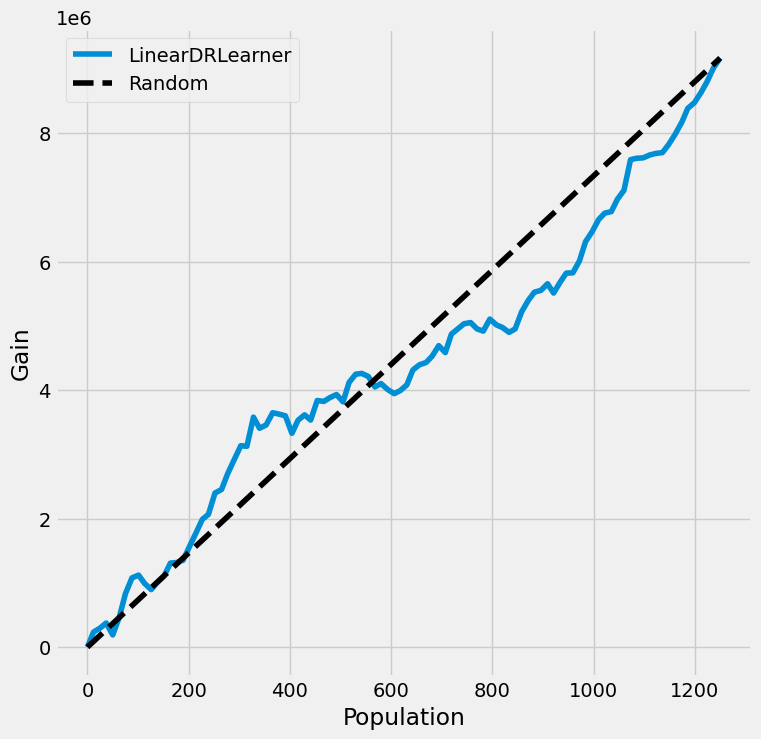

In [103]:
plot_gain(df_eval, outcome_col='conversion', treatment_col='is_treated')

In [104]:
df_eval_tmle = pd.DataFrame({
    'python_proficiency': earnings_interaction_test['python_proficiency'].values,
    'age': earnings_interaction_test['age'],
    'p': propensity_scores,
    'is_treated': earnings_interaction_test['took_a_course'].values,       # 治療組標籤
    'conversion': earnings_interaction_test['earnings'],       # 實際轉化結果
    'LinearDRLearner': effect_pred.flatten() # 模型預測的 Uplift 分數
})

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


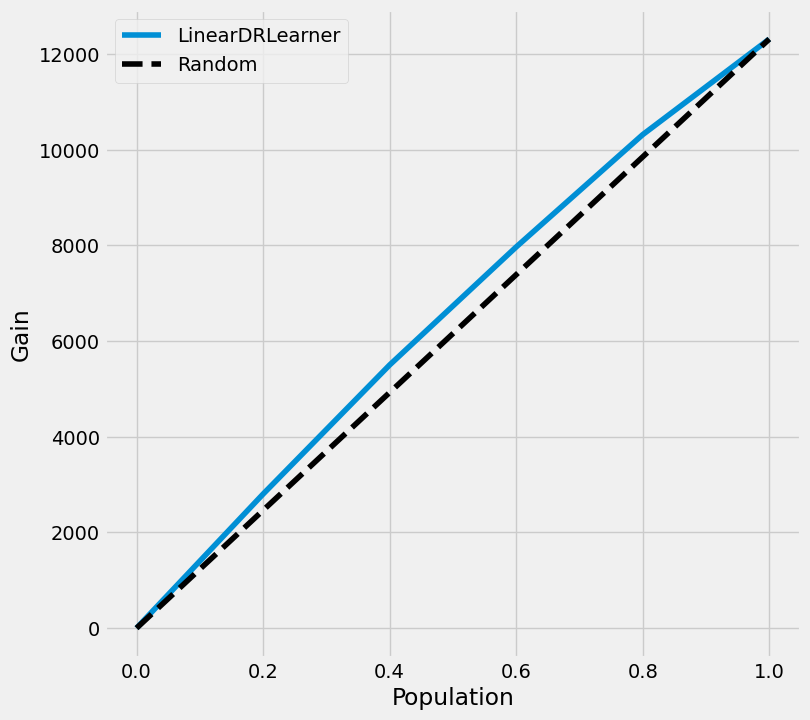

In [105]:
from causalml.metrics import plot_tmlegain
plot_tmlegain(df_eval_tmle, inference_col=['python_proficiency','age'],p_col='p',outcome_col='conversion', treatment_col='is_treated')

In [106]:
df_eval1=df_eval.copy()

In [107]:
df_eval1.columns

Index(['is_treated', 'conversion', 'LinearDRLearner'], dtype='object')

In [108]:
df_eval1_sorted=df_eval1.sort_values(by='LinearDRLearner',ascending=False).reset_index(drop=True)

In [109]:
df_eval1_sorted.iloc[np.linspace(0, df_eval1_sorted.index[-1], 100, endpoint=True)]

,is_treated,conversion,LinearDRLearner
0,True,138534.0,15159.716866
12,False,140911.0,15101.242296
25,False,190620.0,15050.198689
37,True,146959.0,14993.593106
50,False,121739.0,14931.863849
...,...,...,...
1198,False,112358.0,10183.068364
1211,False,115036.0,10139.585192
1223,False,124194.0,10089.859931
1236,False,132263.0,10024.956196


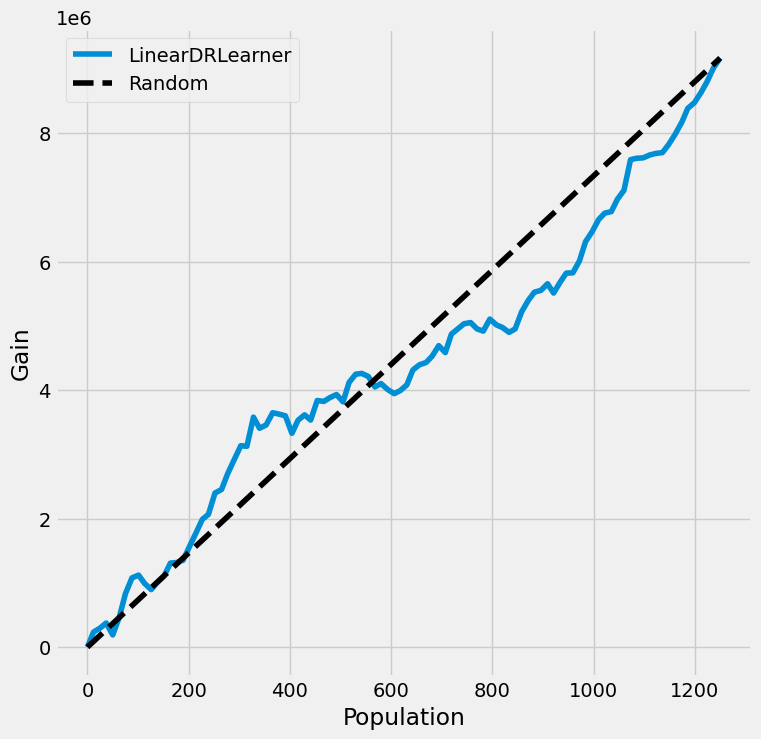

In [110]:
df_eval_final=df_eval[(df_eval.is_treated==1)|(df_eval.is_treated==0)]

plot_gain(df_eval_final, outcome_col='conversion', treatment_col='is_treated')

### Non-linear DR

In [111]:
# Get estimate (Doubly robust)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dr.DRLearner',
    target_units='ate',
    method_params={
        'init_params': {
            'model_propensity': LogisticRegression(),
            'model_regression': LGBMRegressor(n_estimators=1000, max_depth=10),
            'model_final': LGBMRegressor(n_estimators=500, max_depth=10),
        },
        'fit_params': {}
    })

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


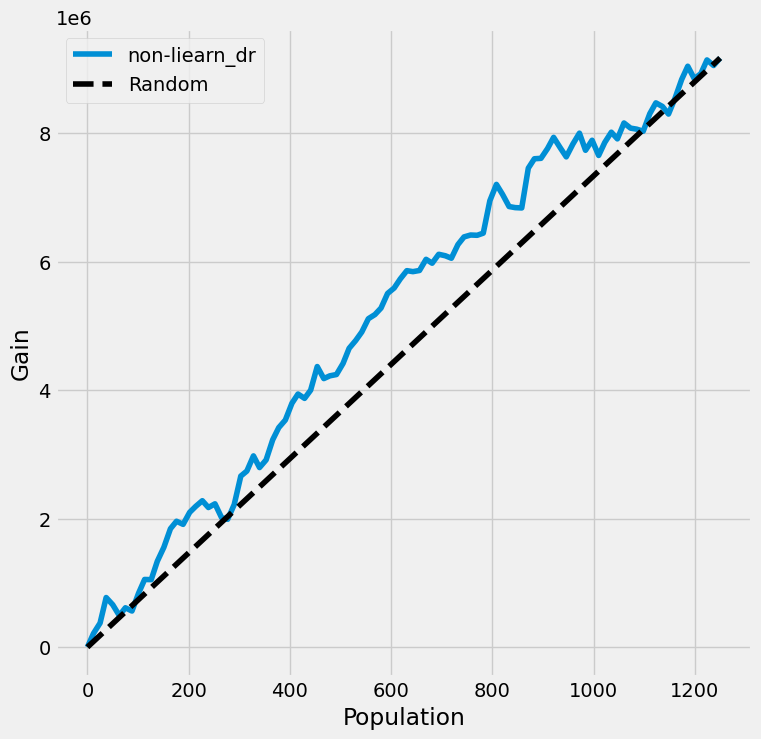

In [112]:
effect_pred = estimate.estimator.effect(earnings_interaction_test.drop(['earnings', 'took_a_course'], axis=1))

from causalml.metrics import plot_gain
df_eval = pd.DataFrame({
    'is_treated': earnings_interaction_test['took_a_course'].values,       # 治療組標籤
    'conversion': earnings_interaction_test['earnings'],       # 實際轉化結果
    'non-liearn_dr': effect_pred.flatten() # 模型預測的 Uplift 分數
})

plot_gain(df_eval, outcome_col='conversion', treatment_col='is_treated')

## If Machine Learning is Cool, How About Double Machine Learning?

### Estimate the effect

In [113]:
# Get estimate (DML)
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dml.LinearDML',
    target_units='ate',
    method_params={
        'init_params': {
            'model_y': LGBMRegressor(n_estimators=500, max_depth=10),
            'model_t': LogisticRegression(),
            'discrete_treatment': True
        },
        'fit_params': {}
    })

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [114]:
estimate.cate_estimates.mean()

np.float64(12587.723709850066)

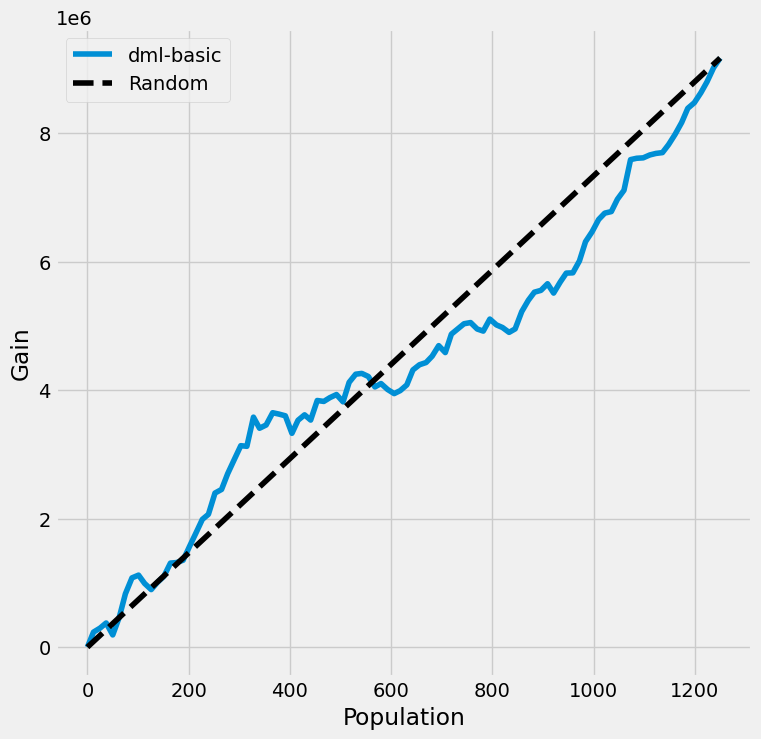

In [115]:
effect_pred = estimate.estimator.effect(earnings_interaction_test.drop(['earnings', 'took_a_course'], axis=1))

from causalml.metrics import plot_gain
df_eval = pd.DataFrame({
    'is_treated': earnings_interaction_test['took_a_course'].values,       # 治療組標籤
    'conversion': earnings_interaction_test['earnings'],       # 實際轉化結果
    'dml-basic': effect_pred.flatten() # 模型預測的 Uplift 分數
})

plot_gain(df_eval, outcome_col='conversion', treatment_col='is_treated')

### DML with more folds

In [116]:
# Estimate the effect
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dml.LinearDML',
    target_units='ate',
    method_params={
        'init_params': {
            'model_y': LGBMRegressor(n_estimators=50, max_depth=10),
            'model_t': LogisticRegression(),
            'discrete_treatment': True,
            'cv': 4
        },
        'fit_params': {
        }
    })

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

In [117]:
estimate.cate_estimates.mean()

np.float64(12703.64757235153)

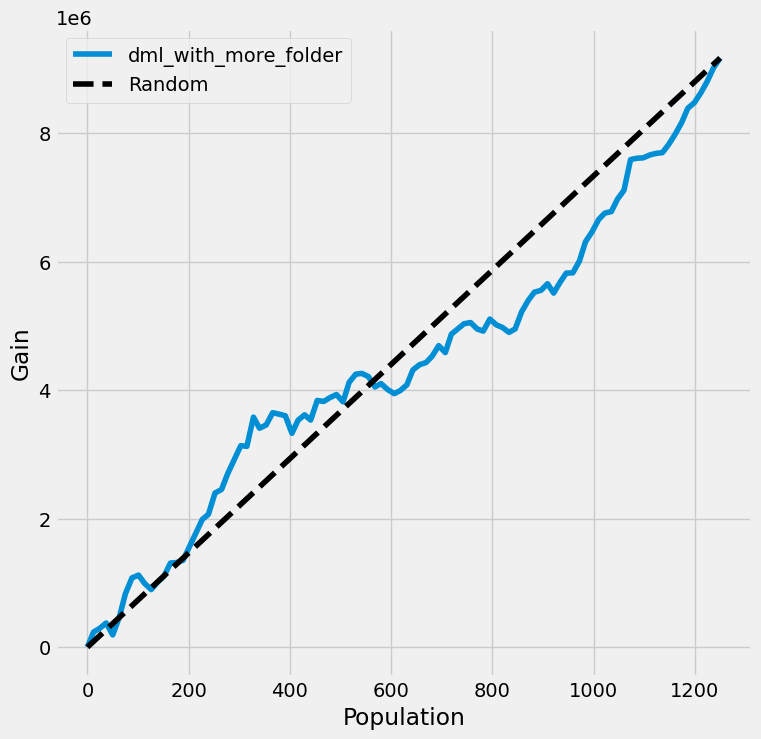

In [118]:
effect_pred = estimate.estimator.effect(earnings_interaction_test.drop(['earnings', 'took_a_course'], axis=1))

from causalml.metrics import plot_gain
df_eval = pd.DataFrame({
    'is_treated': earnings_interaction_test['took_a_course'].values,       # 治療組標籤
    'conversion': earnings_interaction_test['earnings'],       # 實際轉化結果
    'dml_with_more_folder': effect_pred.flatten() # 模型預測的 Uplift 分數
})

plot_gain(df_eval, outcome_col='conversion', treatment_col='is_treated')

### DML with cross-validation

In [119]:
# Define wrapped CV models
model_y = GridSearchCV(
    estimator=LGBMRegressor(),
    param_grid={
        'max_depth': [3, 10, 20, 100],
        'n_estimators': [10, 50, 100]
    }, cv=10, n_jobs=-1, scoring='neg_mean_squared_error'
)

model_t = GridSearchCV(
    estimator=LGBMClassifier(),
    param_grid={
        'max_depth': [3, 10, 20, 100],
        'n_estimators': [10, 50, 100]
    }, cv=10, n_jobs=-1, scoring='accuracy'
)

In [120]:
# Estimate the effect
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dml.LinearDML',
    target_units='ate',
    method_params={
        'init_params': {
            'model_y': model_y,
            'model_t': model_t,
            'discrete_treatment': True,
            'cv': 4
        },
        'fit_params': {
        }
    })

/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model GridSearchCV(cv=10, estimator=LGBMClassifier(), n_jobs=-1,
             param_grid={'max_depth': [3, 10, 20, 100],
                         'n_estimators': [10, 50, 100]},
             scoring='accuracy') has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model GridSearchCV(cv=10, estimator=LGBMRegressor(), n_jobs=-1,
             param_grid={'max_depth': [3, 10, 20, 100],
                         'n_estimators': [10, 50, 100]},
             scoring='neg_mean_squared_error') has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py

In [121]:
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                         
────────────────(E[earnings|age])
d[took_a_course]                 
Estimand assumption 1, Unconfoundedness: If U→{took_a_course} and U→earnings then P(earnings|took_a_course,age,U) = P(earnings|took_a_course,age)

## Realized estimand
b: earnings~took_a_course+age | python_proficiency
Target units: ate

## Estimate
Mean value: 12642.954746986165
Effect estimates: [[14359.88096164]
 [13632.84605506]
 [13344.57618457]
 ...
 [14146.19560899]
 [10793.9002009 ]
 [11287.87388132]]



In [122]:
estimate.cate_estimates.mean()

np.float64(12642.954746986165)

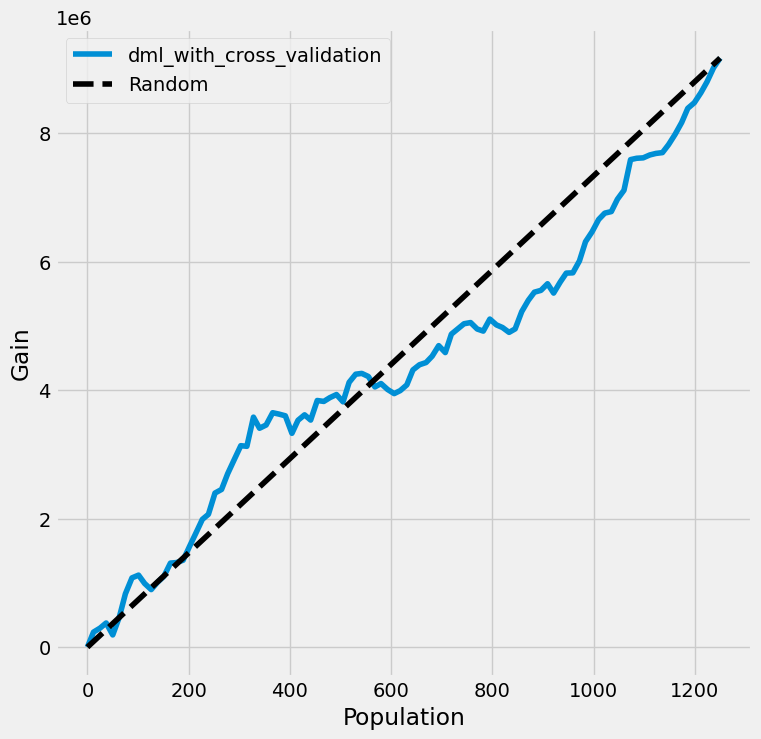

In [123]:
effect_pred = estimate.estimator.effect(earnings_interaction_test.drop(['earnings', 'took_a_course'], axis=1))

from causalml.metrics import plot_gain
df_eval = pd.DataFrame({
    'is_treated': earnings_interaction_test['took_a_course'].values,       # 治療組標籤
    'conversion': earnings_interaction_test['earnings'],       # 實際轉化結果
    'dml_with_cross_validation': effect_pred.flatten() # 模型預測的 Uplift 分數
})

plot_gain(df_eval, outcome_col='conversion', treatment_col='is_treated')

## Causal Forests and more

In [124]:
# Estimate the effect
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dml.CausalForestDML',
    target_units='ate',
    method_params={
        'init_params': {
            'model_y': LGBMRegressor(n_estimators=50, max_depth=10),
            'model_t': LGBMClassifier(n_estimators=50, max_depth=10),
            'discrete_treatment': True,
            'cv': 4
        },
        'fit_params': {
        }
    }
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils

In [125]:
estimate.cate_estimates.mean()

np.float64(12437.617099368787)

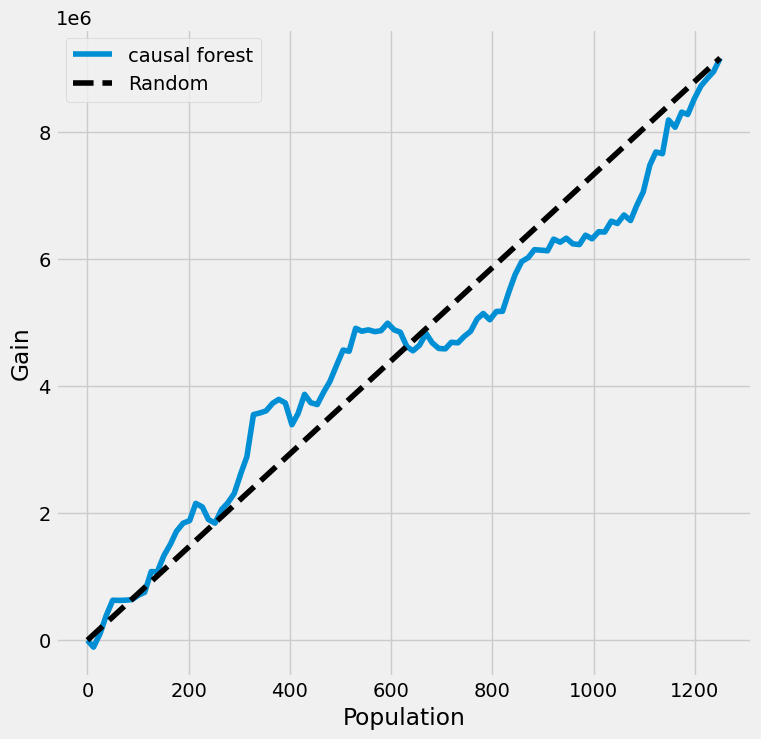

In [126]:
effect_pred = estimate.estimator.effect(earnings_interaction_test.drop(['earnings', 'took_a_course'], axis=1))

from causalml.metrics import plot_gain
df_eval = pd.DataFrame({
    'is_treated': earnings_interaction_test['took_a_course'].values,       # 治療組標籤
    'conversion': earnings_interaction_test['earnings'],       # 實際轉化結果
    'causal forest': effect_pred.flatten() # 模型預測的 Uplift 分數
})

plot_gain(df_eval, outcome_col='conversion', treatment_col='is_treated')

## Heterogenous Treatment Effects With Experimental Data

In [127]:
!wget https://raw.githubusercontent.com/PacktPublishing/Causal-Inference-and-Discovery-in-Python/refs/heads/main/data/hillstrom_clean_label_mapping.json

--2026-04-08 09:52:09--  https://raw.githubusercontent.com/PacktPublishing/Causal-Inference-and-Discovery-in-Python/refs/heads/main/data/hillstrom_clean_label_mapping.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50 [text/plain]
Saving to: ‘hillstrom_clean_label_mapping.json’

hillstrom_clean_lab 100%[===================>]      50  --.-KB/s    in 0s      

2026-04-08 09:52:10 (775 KB/s) - ‘hillstrom_clean_label_mapping.json’ saved [50/50]



In [128]:
# Read in the data
hillstrom_clean = pd.read_csv(r'https://raw.githubusercontent.com/PacktPublishing/Causal-Inference-and-Discovery-in-Python/refs/heads/main/data/hillstrom_clean.csv')








# Read in labels mapping
with open(r'hillstrom_clean_label_mapping.json', 'r') as f:
    hillstrom_labels_mapping = json.load(f)

In [129]:
hillstrom_clean.head()

,recency,history,mens,womens,newbie,visit,conversion,spend,zip_code__rural,zip_code__surburban,zip_code__urban,channel__multichannel,channel__phone,channel__web,treatment
0,10,142.44,1,0,0,0,0,0.0,0,1,0,0,1,0,1
1,6,329.08,1,1,1,0,0,0.0,1,0,0,0,0,1,0
2,7,180.65,0,1,1,0,0,0.0,0,1,0,0,0,1,1
3,9,675.83,1,0,1,0,0,0.0,1,0,0,0,0,1,2
4,2,45.34,1,0,0,0,0,0.0,0,0,1,0,0,1,1


In [130]:
# Drop redundant cols to avoid multicollinearity
hillstrom_clean = hillstrom_clean.drop(['zip_code__urban', 'channel__web'], axis=1)

### EDA

In [131]:
# Display mapping
hillstrom_labels_mapping

{'control': 0, 'womans_email': 1, 'mens_email': 2}

In [132]:
# P(visit)
hillstrom_clean.visit.mean()

np.float64(0.14678125)

In [133]:
# P(conversion)
hillstrom_clean.conversion.mean()

np.float64(0.00903125)

In [134]:
# Get sample size
sample_size = hillstrom_clean.shape[0]

In [135]:
# Check how random is the treatment assignment

# Split data
hillstrom_X = hillstrom_clean.drop(['visit', 'conversion', 'spend', 'treatment'], axis=1)
hillstrom_Y = hillstrom_clean['spend']
hillstrom_T = hillstrom_clean['treatment']

In [136]:
# P(T=t)
hillstrom_T.value_counts() / sample_size

,count
treatment,
1,0.334172
2,0.332922
0,0.332906


In [137]:
# Train-test split
X_train_eda, X_test_eda, T_train_eda, T_test_eda = train_test_split(hillstrom_X, hillstrom_T, test_size=.5)

In [138]:
# Split quality
T_test_eda.value_counts() / T_test_eda.shape[0]

,count
treatment,
1,0.335562
0,0.333313
2,0.331125


In [139]:
# Fit the EDA model
lgbm_eda = LGBMClassifier()
lgbm_eda.fit(X_train_eda, T_train_eda)

LGBMClassifier()

In [140]:
# Get predictions on the test
T_pred_eda = lgbm_eda.predict(X_test_eda)

# Check accuracy
acc_eda = accuracy_score(T_test_eda, T_pred_eda)
acc_eda

0.33125

In [141]:
# Generate random data
random_scores = []

test_eda_sample_size = T_test_eda.shape[0]

for i in range(10000):
    random_scores.append(
        (np.random.choice(
            [0, 1, 2],
            test_eda_sample_size) == np.random.choice(
            [0, 1, 2],
            test_eda_sample_size)).mean())

np.quantile(random_scores, .025), np.quantile(random_scores, .975)

(0.32821796875, 0.3383125)

In [142]:
# Get 95% CIs
lower = np.quantile(random_scores, .025)
upper = np.quantile(random_scores, .975)
lower, upper

(0.32821796875, 0.3383125)

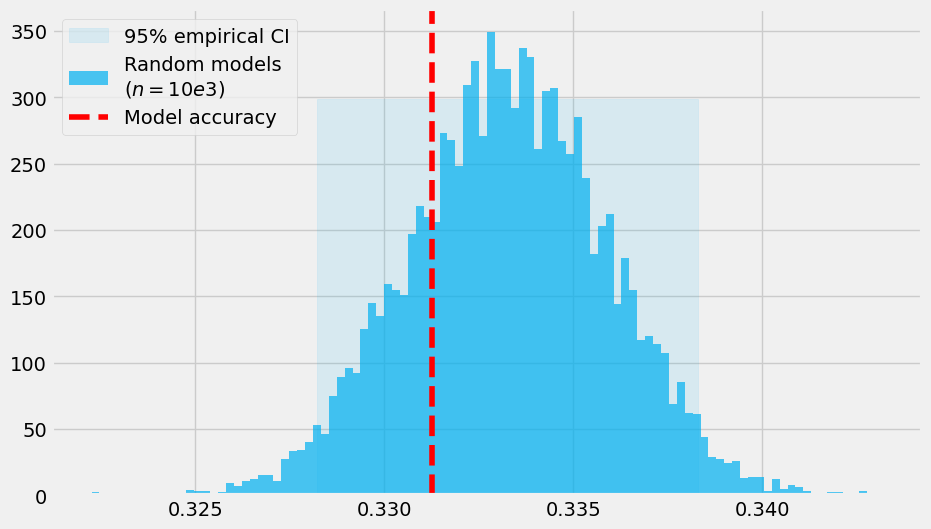

In [143]:
# Plot radom vs accuracy
plt.figure(figsize=(10, 6))
plt.fill_betweenx(
    x1=lower,
    x2=upper,
    y=np.arange(0, 300),
    color=COLORS[0],
    alpha=.1,
    label='95% empirical CI'
)
plt.hist(random_scores, alpha=.7, color=COLORS[0], bins=100, label='Random models\n($n=10e3$)')
plt.axvline(acc_eda, color=COLORS[1], ls='--', label='Model accuracy')

plt.legend()
plt.show()

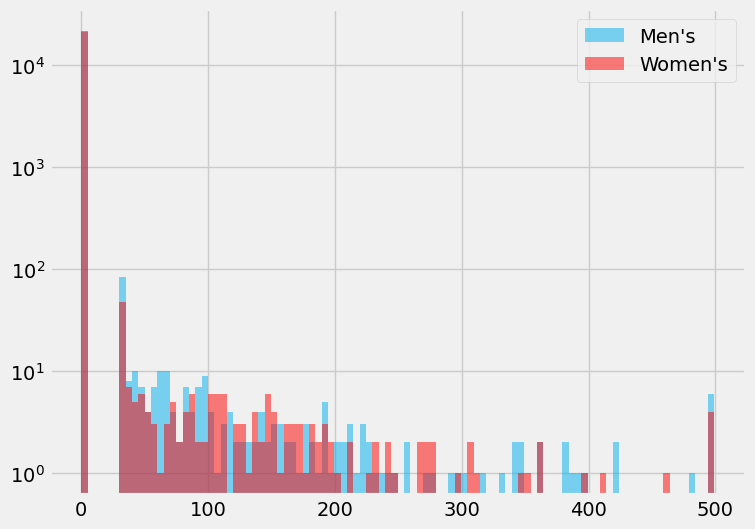

In [144]:
plt.figure(figsize=(8, 6))

plt.hist(
    hillstrom_clean[hillstrom_clean['treatment'] == 2]['spend'],
    label=f'Men\'s',
    color=COLORS[0],
    bins=100,
    alpha=.5)

plt.hist(
    hillstrom_clean[hillstrom_clean['treatment'] == 1]['spend'],
    label=f'Women\'s',
    color=COLORS[1],
    bins=100,
    alpha=.5)

plt.legend()
plt.yscale('log')
plt.show()

In [145]:
hillstrom_clean[hillstrom_clean['treatment'] == 1]['spend'].var()

228.49667483464316

In [146]:
hillstrom_labels_mapping

{'control': 0, 'womans_email': 1, 'mens_email': 2}

### Modeling Hillstrom

In [147]:
# No. of conversions
(hillstrom_Y[hillstrom_T > 0] > 0).sum()

np.int64(456)

In [148]:
# Train test split
X_train, X_test, y_train, y_test, T_train, T_test = train_test_split(
    hillstrom_X,
    hillstrom_Y,
    hillstrom_T,
    test_size=.5
)

In [149]:
# How many observations in train/test converted?
(y_train[T_train > 0] > 0).sum(), (y_test[T_test > 0] > 0).sum()

(np.int64(207), np.int64(249))

In [150]:
def create_model(model_type, n_estimators=100, max_depth=10, learning_rate=.01):
    if model_type == 'regressor':
        return LGBMRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate)
    elif model_type == 'classifier':
        return LGBMClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate)
    else:
        raise NotImplementedError(f'Model type `{model_type}` not implemented.')

In [151]:
# Models
s_learner = SLearner(
    overall_model=create_model('regressor')
)

x_learner = XLearner(
    models=[
        create_model('regressor'),
        create_model('regressor'),
        create_model('regressor'),
    ],
    cate_models=[
        create_model('regressor'),
        create_model('regressor'),
        create_model('regressor'),
    ]
)

t_learner = TLearner(
    models=[
        create_model('regressor'),
        create_model('regressor'),
        create_model('regressor'),
    ]
)

dml = LinearDML(
    model_y=create_model('regressor'),
    model_t=create_model('classifier'),
    discrete_treatment=True,
    cv=5
)

dr = DRLearner(
    model_propensity=LogisticRegression(),
    model_regression=create_model('regressor'),
    model_final=create_model('regressor'),
    cv=5,
)

cf = CausalForestDML(
    model_y=create_model('regressor'),
    model_t=create_model('classifier'),
    discrete_treatment=True,
    cv=5
)

In [152]:
# Models
models = {
    'SLearner': s_learner,
    'TLearner': t_learner,
    'XLearner': x_learner,
    'DRLearner': dr,
    'LinearDML': dml,
    'CausalForestDML': cf
}

In [153]:
# Fit the estimator
for model_name, model in models.items():
    start = time.time()
    print(f'Fitting {model_name}')
    model.fit(
        Y=y_train,
        T=T_train,
        X=X_train
    )
    stop = time.time()

    print(f'{model_name} fitted in {stop - start:0.4f} seconds.\n')

Fitting SLearner
SLearner fitted in 0.2827 seconds.

Fitting TLearner
TLearner fitted in 0.3632 seconds.

Fitting XLearner


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid fe

XLearner fitted in 1.4907 seconds.

Fitting DRLearner


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid fe

DRLearner fitted in 10.1325 seconds.

Fitting LinearDML


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils

LinearDML fitted in 6.6151 seconds.

Fitting CausalForestDML


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils

CausalForestDML fitted in 15.6792 seconds.



In [154]:
# Compute effects
effects_train = {
    'treatment_1': {},
    'treatment_2': {}
}

effects_test = {
    'treatment_1': {},
    'treatment_2': {}
}


for treatment in [1, 2]:
    for model_name, model in tqdm(models.items()):

        # Compute effects on train
        effects_local_train = models[model_name].effect(X_train.values, T0=0, T1=treatment)
        effects_train[f'treatment_{treatment}'][model_name] = effects_local_train

        # Compute effects on test
        effects_local_test = models[model_name].effect(X_test.values, T0=0, T1=treatment)
        effects_test[f'treatment_{treatment}'][model_name] = effects_local_test


  0%|          | 0/6 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
 17%|█▋        | 1/6 [00:00<00:03,  1.40it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 

#### Uplift by decile

In [155]:
# def get_uplift_by_decile(uplifts, t_true, t_pred, y_true):

#     # Encapsulate the data & sort according to uplifts
#     all_data = pd.DataFrame(
#         dict(
#             uplifts=uplifts,
#             y_true=y_true,
#             t_true=t_true)
#     ).query(f't_true==0 | t_true=={t_pred}').sort_values('uplifts')

#     # Partition into deciles
#     all_data['deciles'] = pd.qcut(all_data['uplifts'], q=10, labels=np.arange(10), duplicates='drop')

#     # Get mean responses within deciles
#     mean_decile_resp = all_data.groupby(['deciles', 't_true']).mean()

#     # Compute true decile uplift
#     mean_decile_resp['true_uplift'] = mean_decile_resp['y_true'] * np.array([-1, 1]*10)
#     true_uplift = mean_decile_resp.groupby(level=[0]).sum()['true_uplift']

#     return true_uplift[::-1]

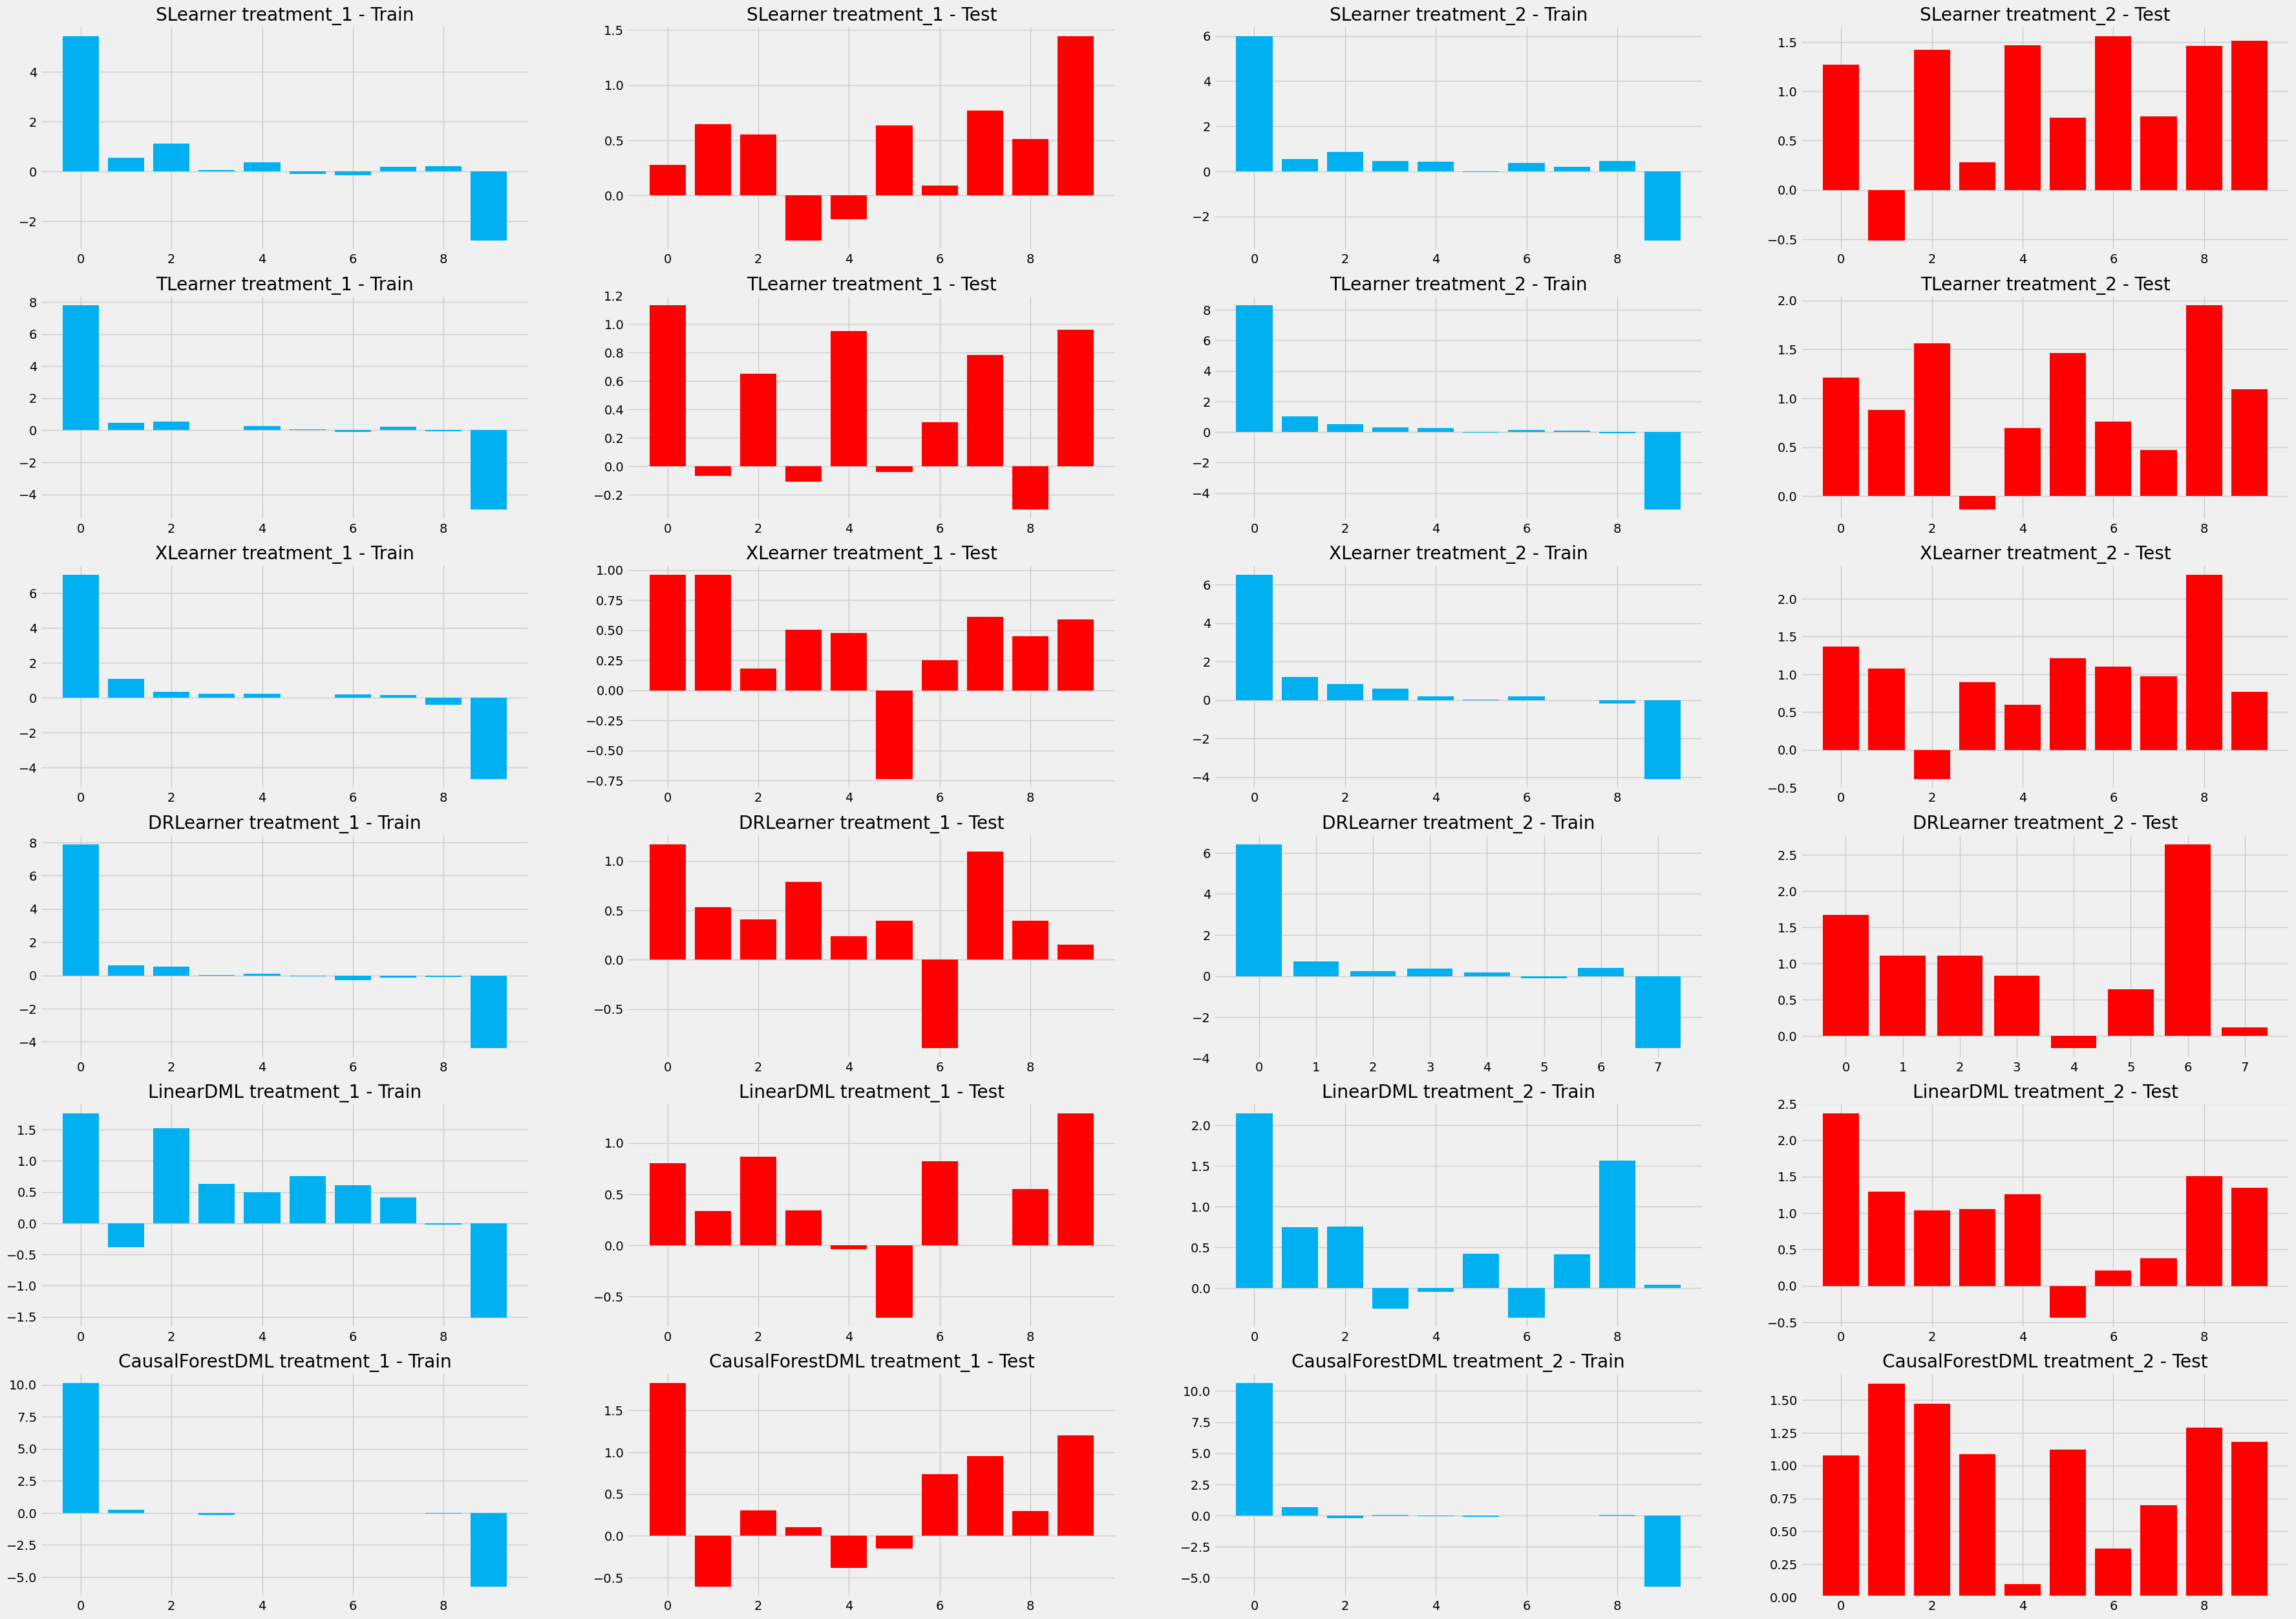

In [156]:
def get_uplift_by_decile(uplifts, t_true, t_pred, y_true):

    # Encapsulate the data & sort according to uplifts
    all_data = pd.DataFrame(
        dict(
            uplifts=uplifts,
            y_true=y_true,
            t_true=t_true)
    ).query(f't_true==0 | t_true=={t_pred}').sort_values('uplifts')

    # Partition into deciles
    # Let pd.qcut assign labels automatically as integer indicators
    # This handles cases where `duplicates='drop'` results in fewer than `q` unique bins.
    all_data['deciles'] = pd.qcut(all_data['uplifts'], q=10, duplicates='drop', labels=False)

    # Get mean responses within deciles, unstack to separate treatments into columns
    mean_decile_resp = all_data.groupby(['deciles', 't_true']).mean().unstack(level='t_true')

    # Compute true decile uplift
    control_col = 0
    treatment_col = t_pred

    # Ensure both control and treatment columns exist after unstacking
    # Fill missing columns with 0 if a treatment/control group is not present in a decile
    if control_col not in mean_decile_resp['y_true'].columns:
        mean_decile_resp['y_true'][control_col] = 0
    if treatment_col not in mean_decile_resp['y_true'].columns:
        mean_decile_resp['y_true'][treatment_col] = 0

    # Calculate uplift: Treatment - Control
    true_uplift = mean_decile_resp['y_true'][treatment_col] - mean_decile_resp['y_true'][control_col]

    return true_uplift[::-1]


plt.figure(figsize=(40, 30))

i = 1

for model_name in models.keys():

    uplifts_by_decile = {
        'treatment_1': {},
        'treatment_2': {}
    }

    global_min = np.inf
    global_max = -np.inf

    for treatment in ['treatment_1', 'treatment_2']:

        uplift_by_decile_train = get_uplift_by_decile(
            uplifts=effects_train[treatment][model_name],
            t_true=T_train,
            t_pred=int(treatment.split('_')[-1]),
            y_true=y_train
        )

        uplift_by_decile_test = get_uplift_by_decile(
            uplifts=effects_test[treatment][model_name],
            t_true=T_test,
            t_pred=int(treatment.split('_')[-1]),
            y_true=y_test
        )

        plt.subplot(6, 4, i)
        plt.bar(np.arange(len(uplift_by_decile_train)), uplift_by_decile_train, color=COLORS[0])
        plt.title(f'{model_name} {treatment} - Train')

        plt.subplot(6, 4, i + 1)
        plt.bar(np.arange(len(uplift_by_decile_test)), uplift_by_decile_test, color=COLORS[1])
        plt.title(f'{model_name} {treatment} - Test')

        i += 2

plt.show()

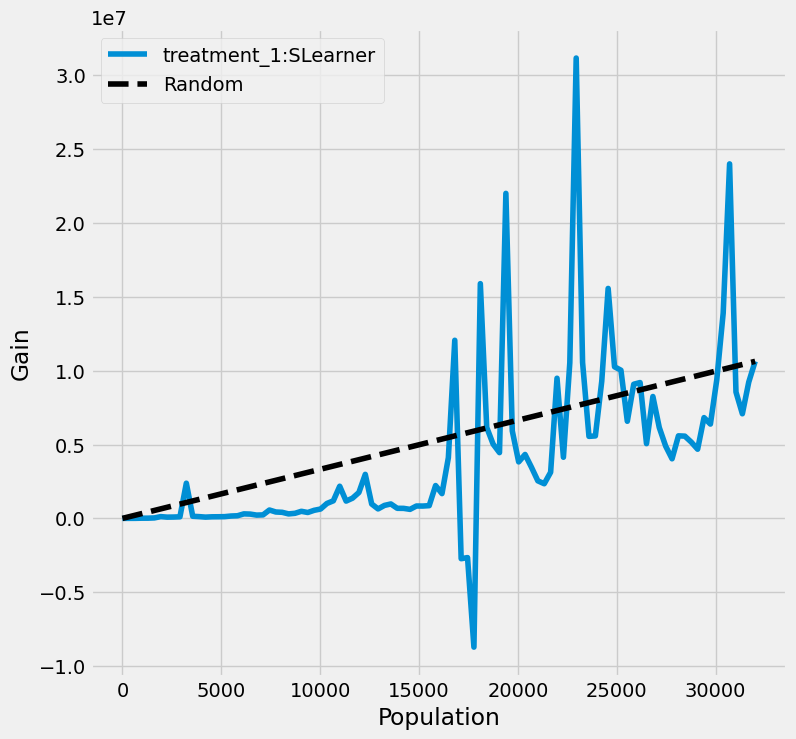

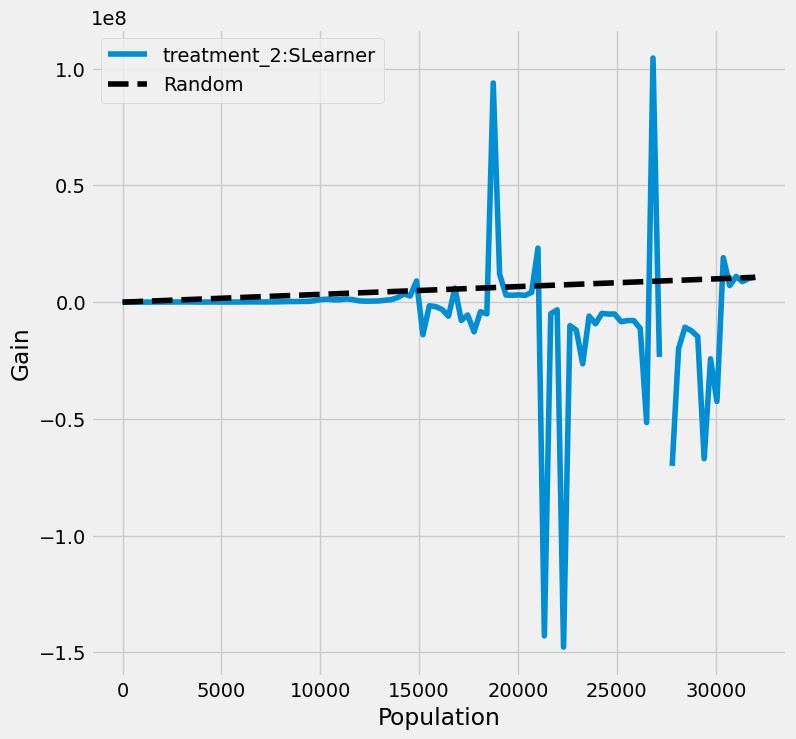

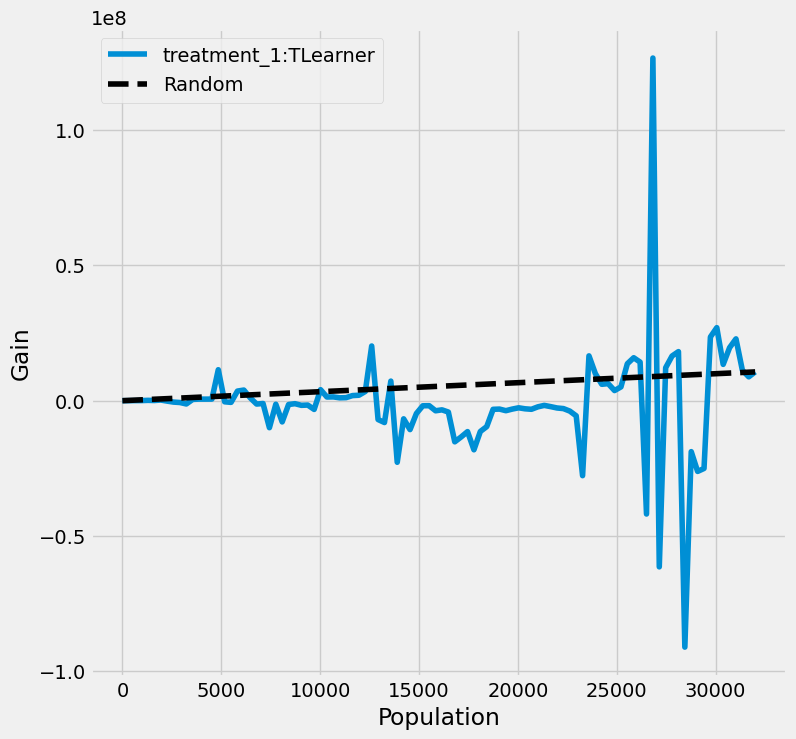

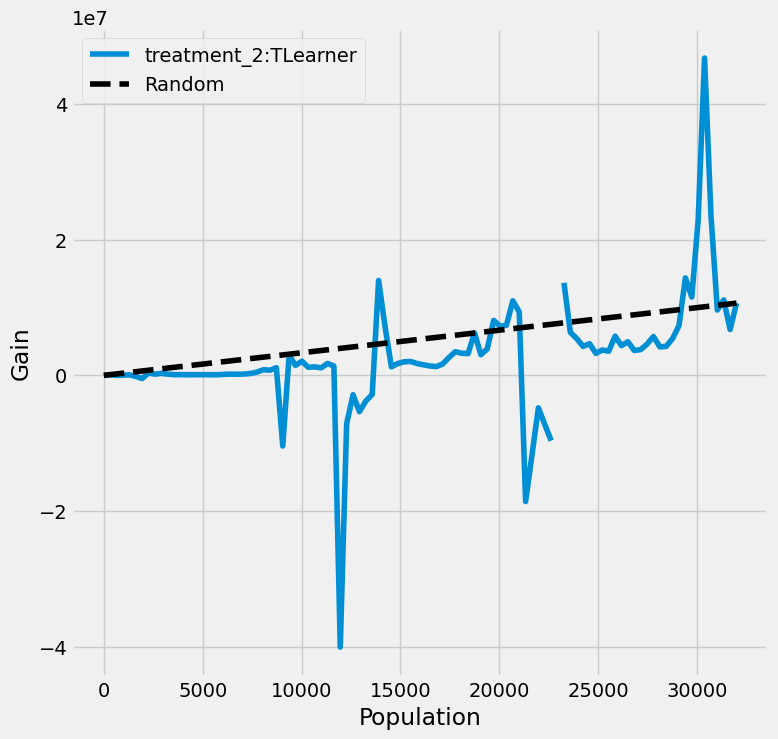

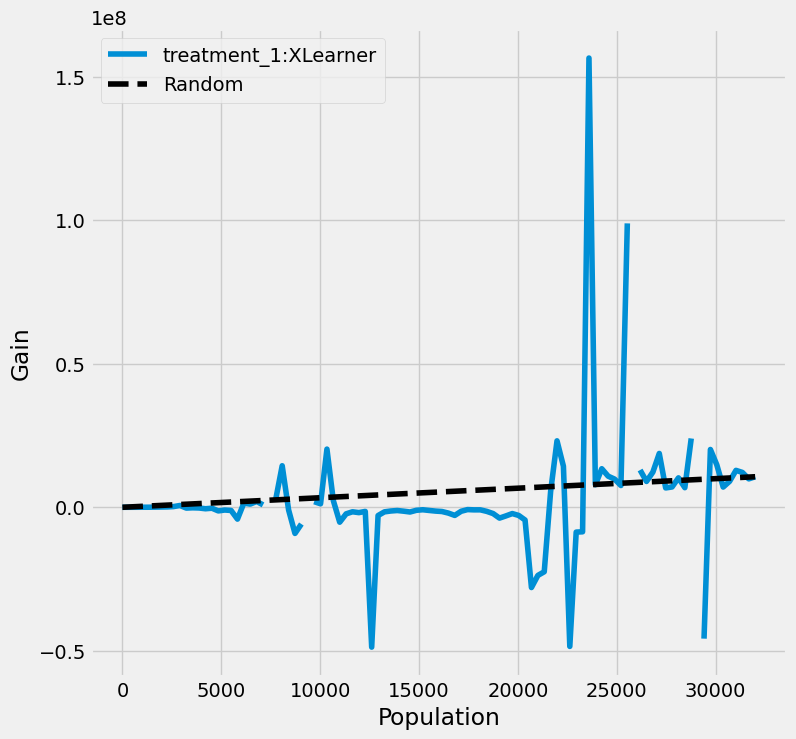

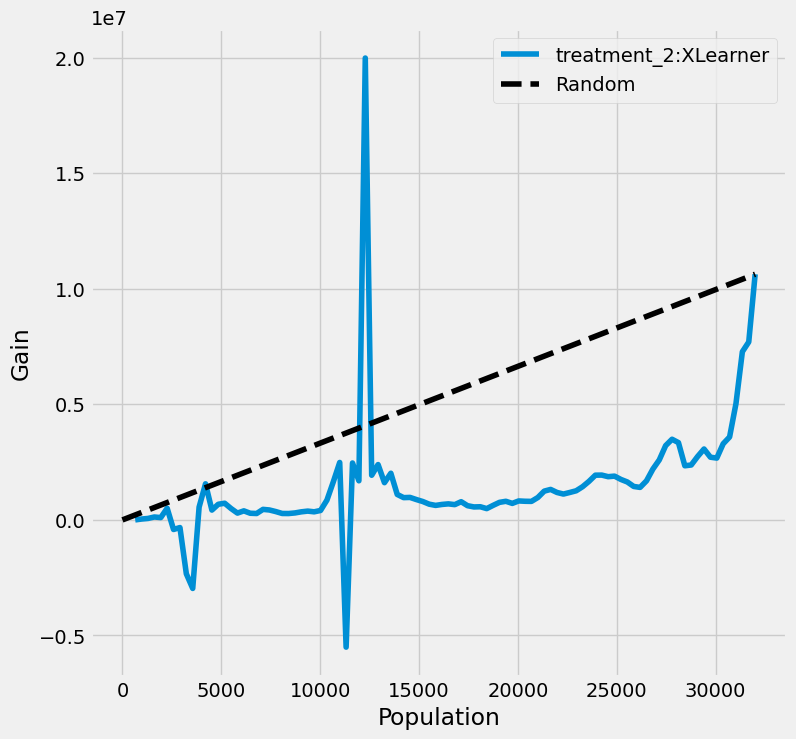

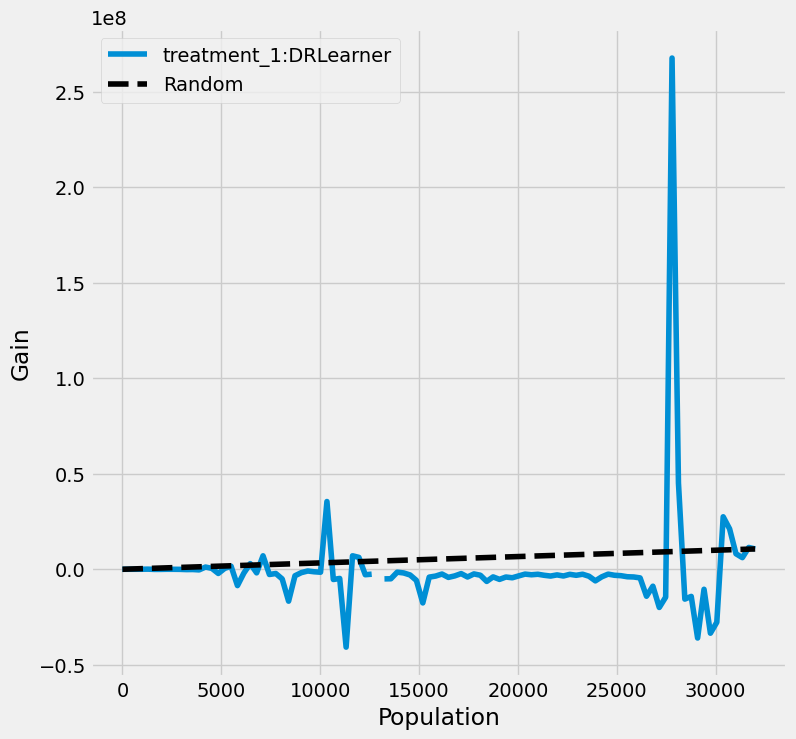

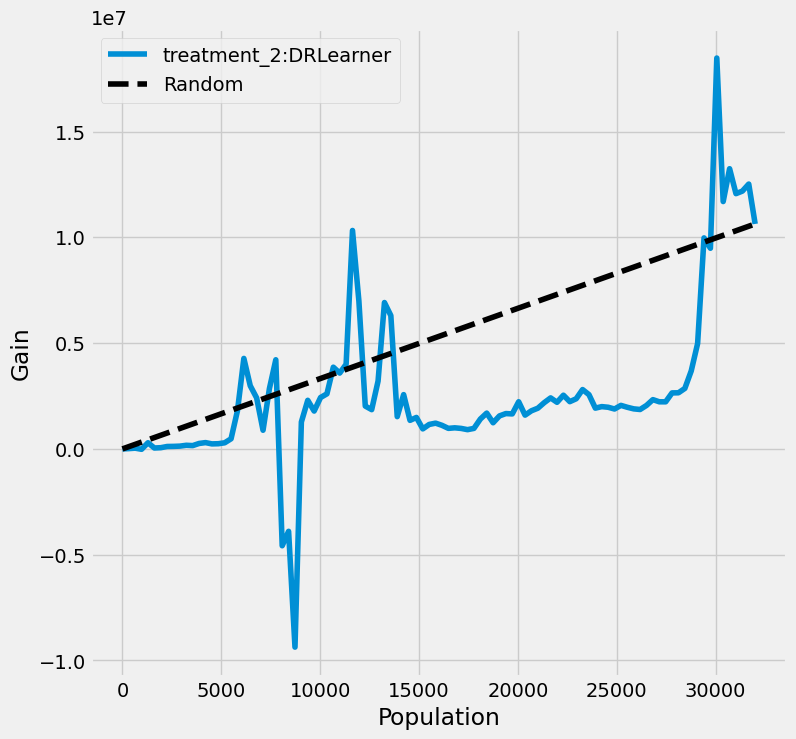

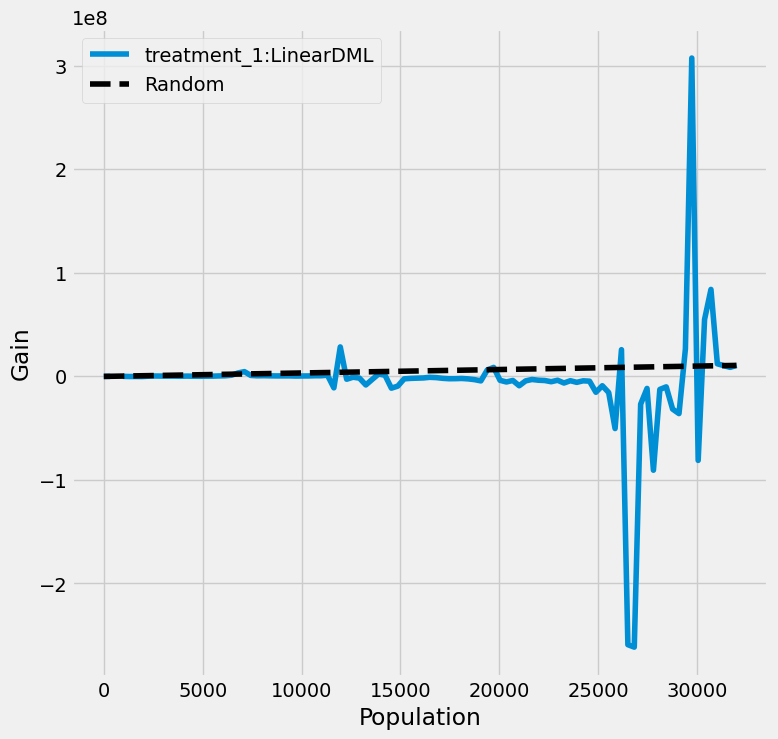

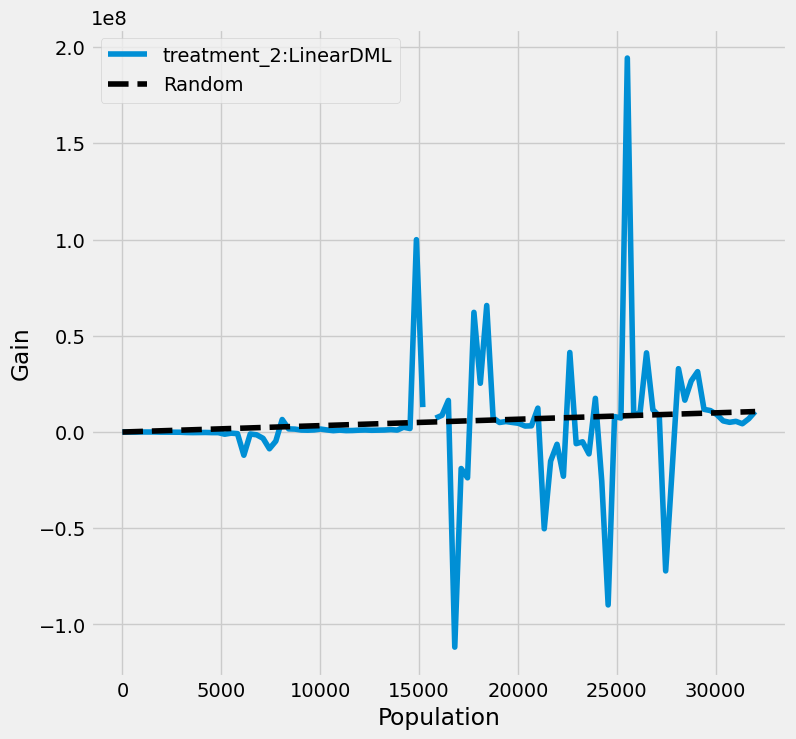

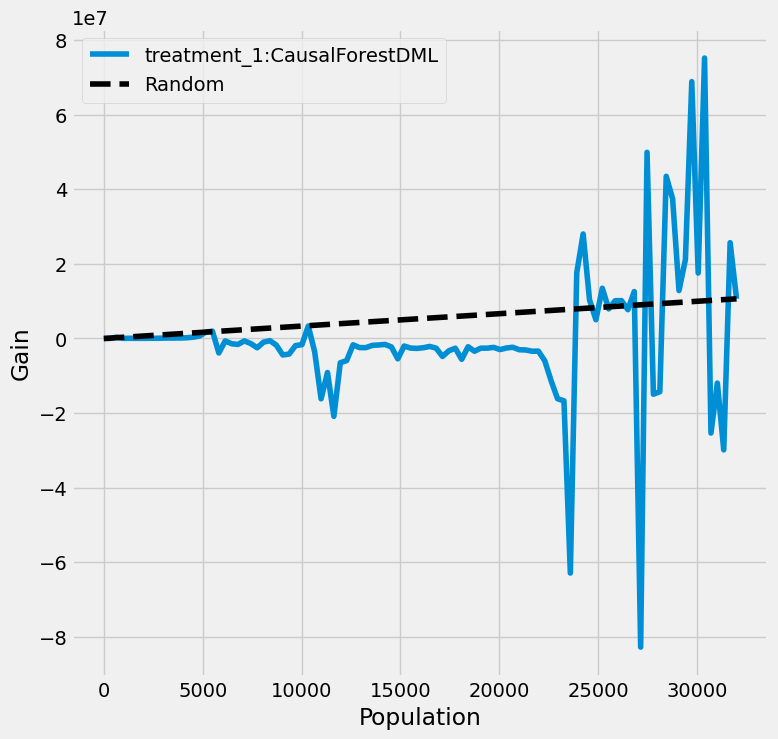

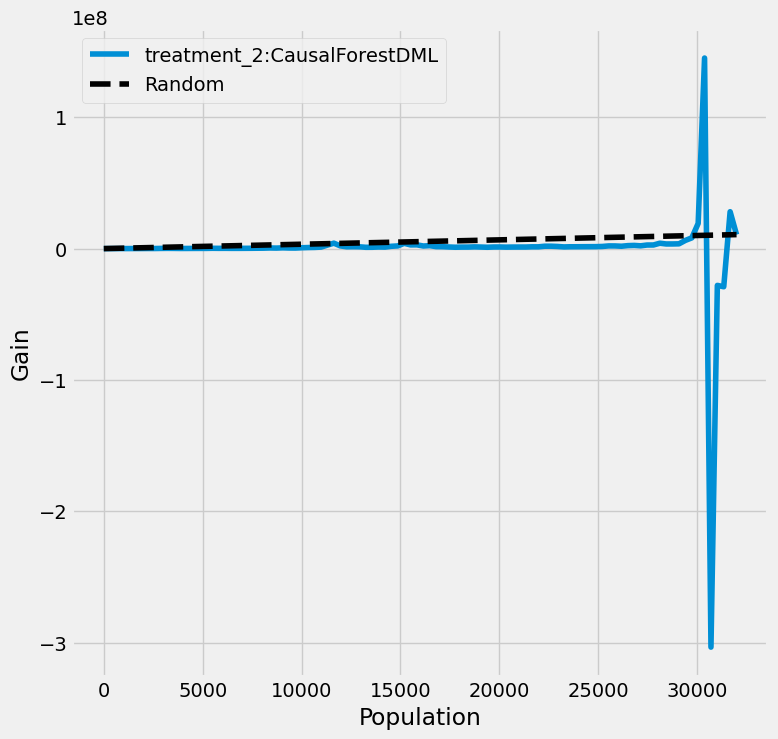

In [157]:
for model in models.keys():
  for treatment in ['treatment_1', 'treatment_2']:
    effect_pred=effects_test[treatment][model]
    df_eval = pd.DataFrame({
    'is_treated': T_test,       # 治療組標籤
    'conversion': y_test,       # 實際轉化結果
    f'{treatment}:{model}': effect_pred.flatten() # 模型預測的 Uplift 分數
})
    plot_gain(df_eval, outcome_col='conversion', treatment_col='is_treated')


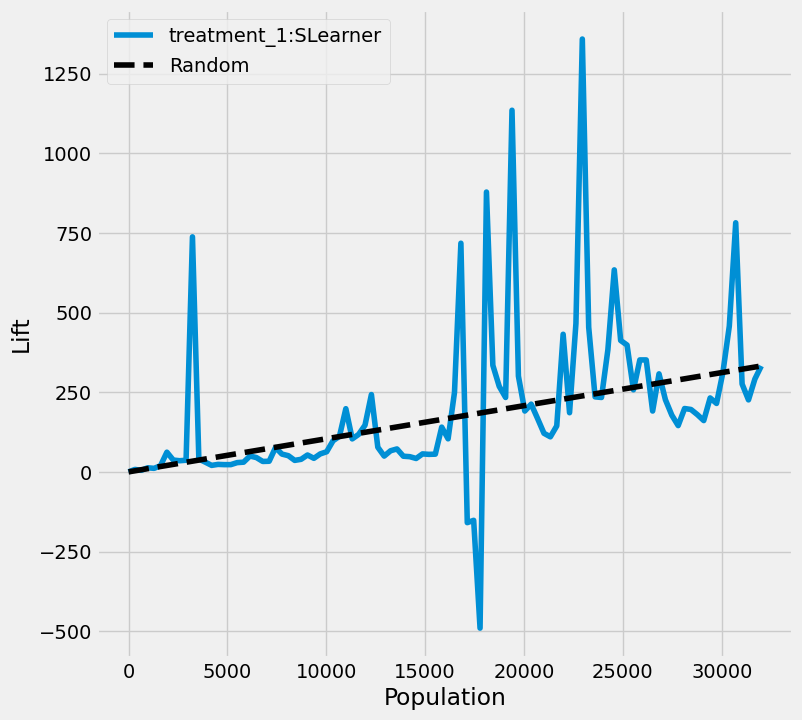

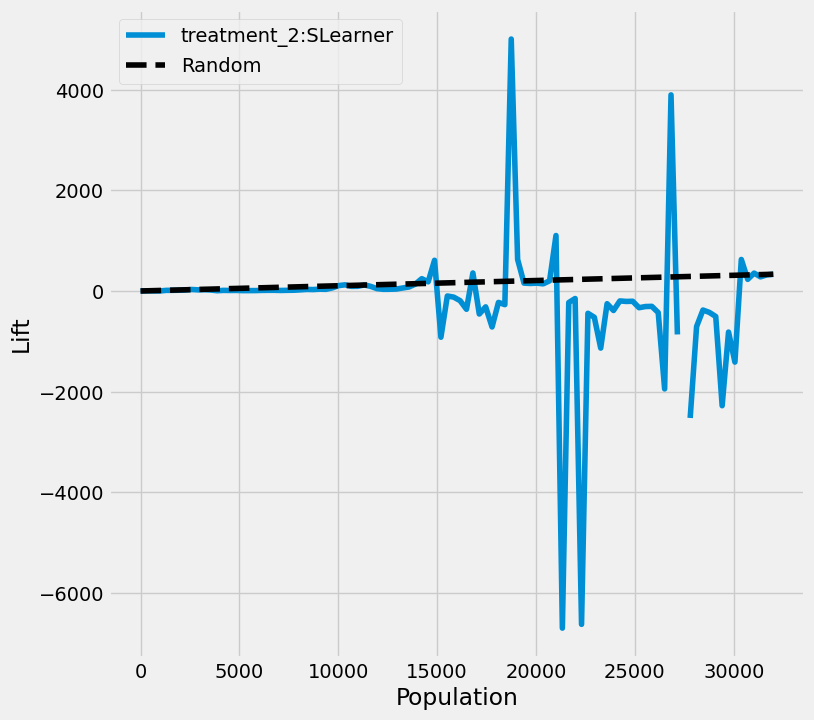

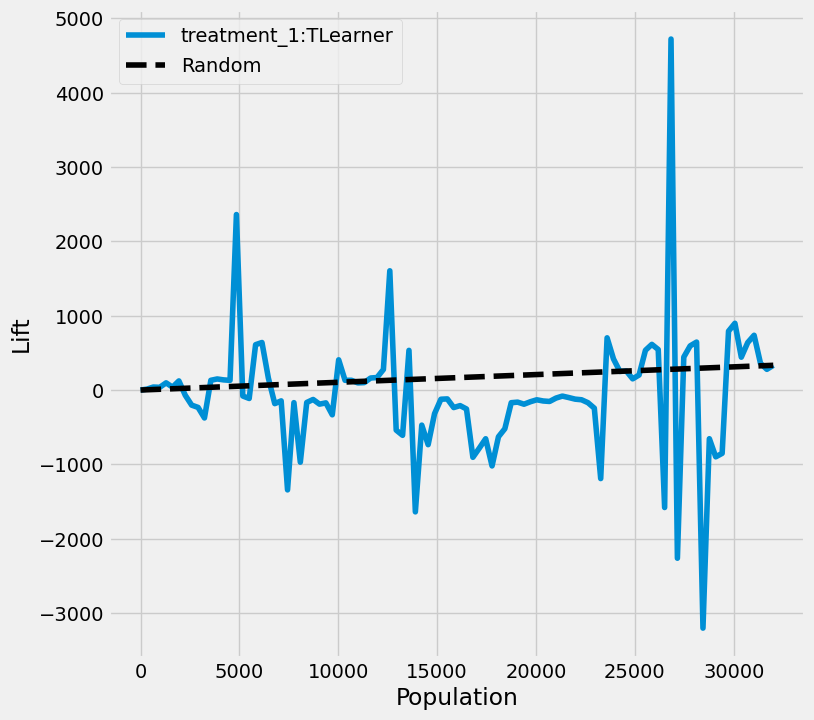

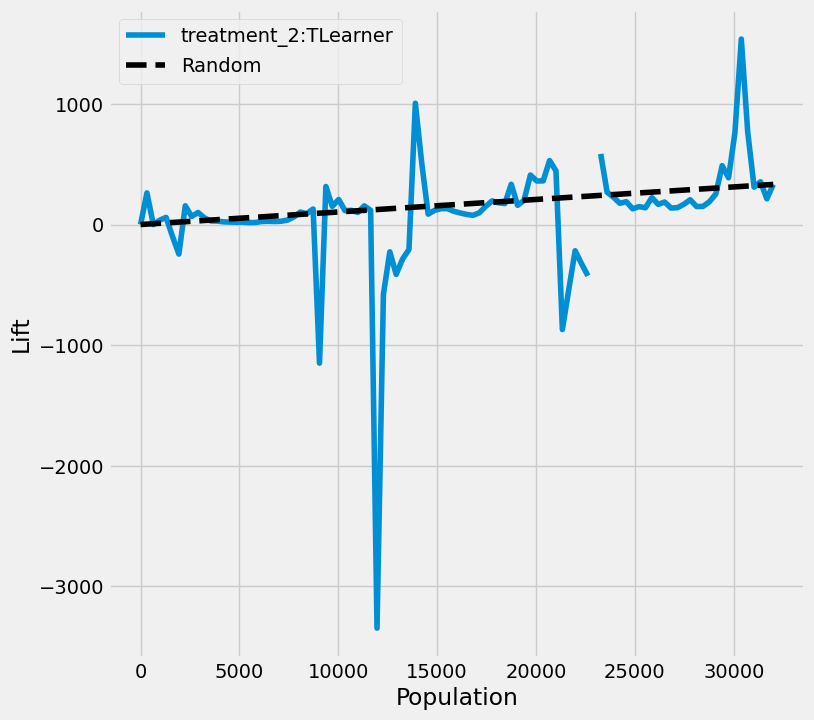

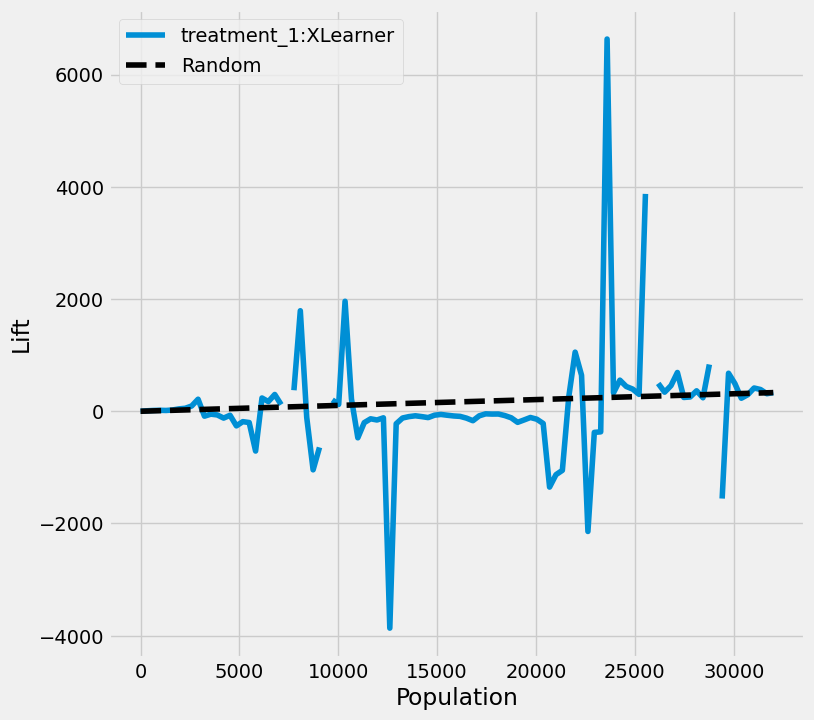

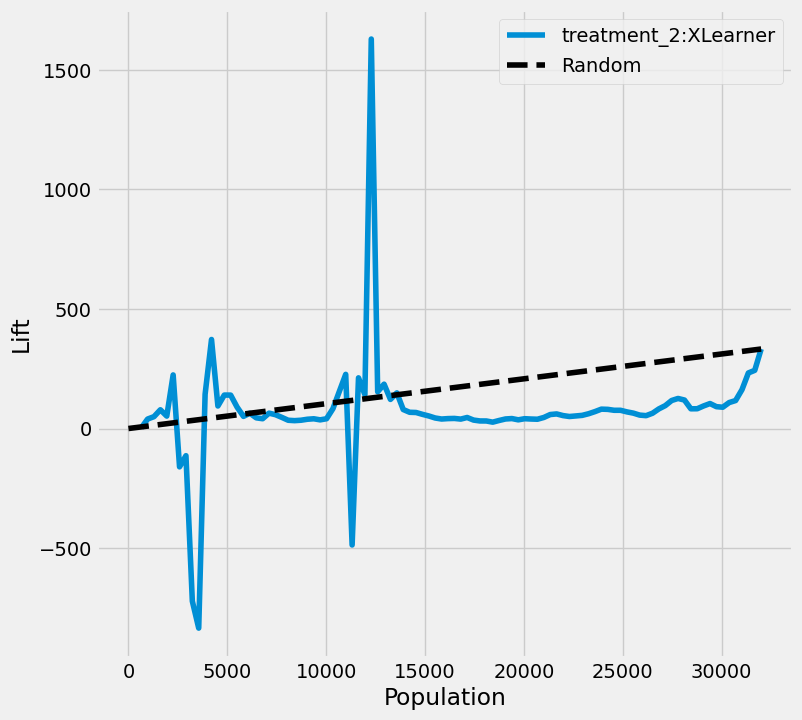

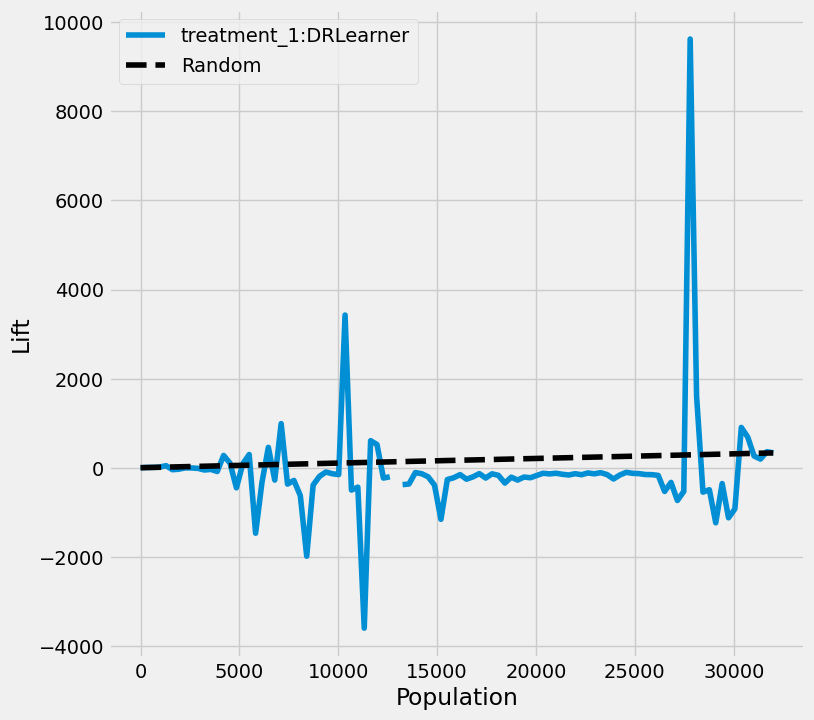

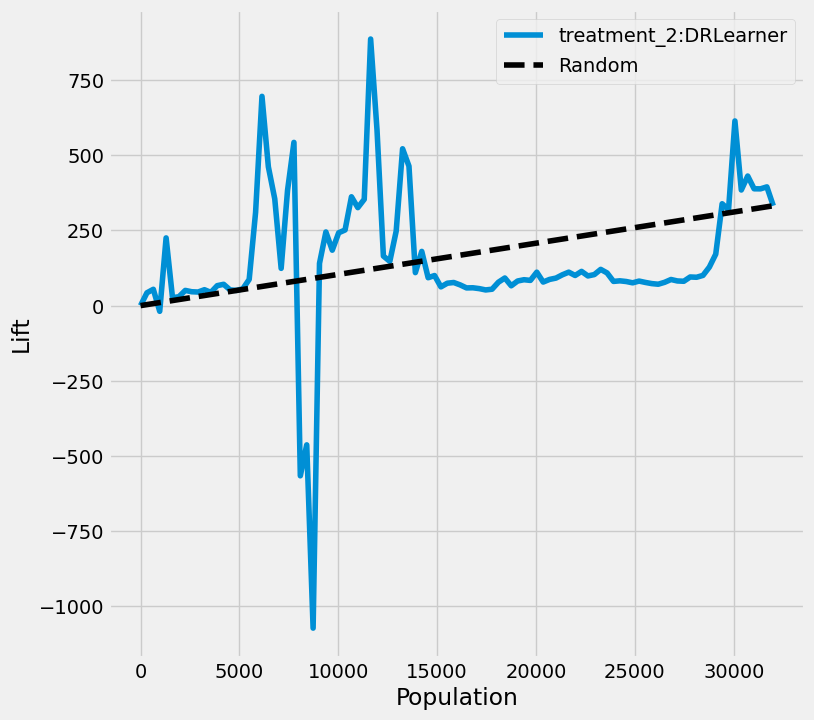

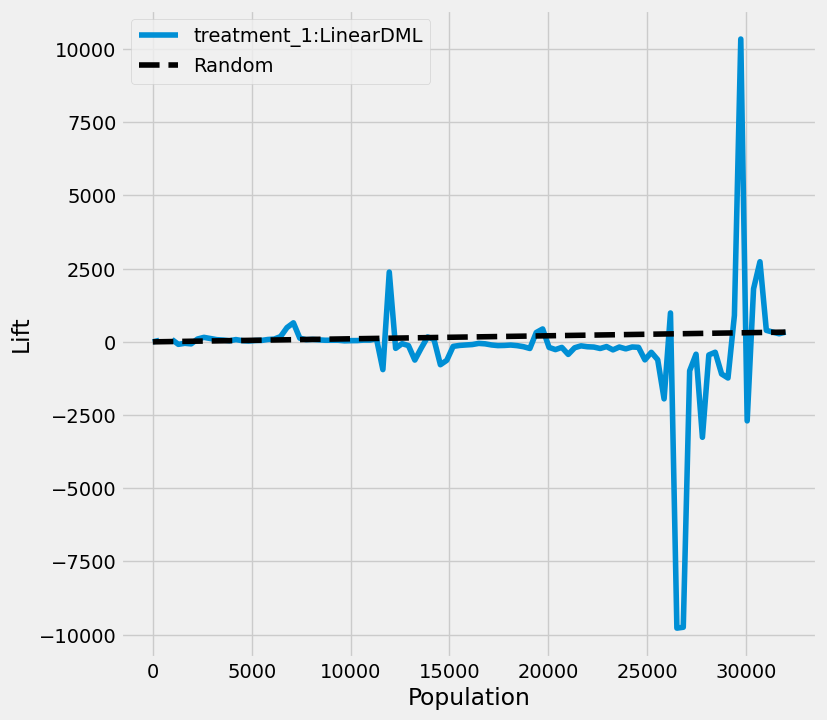

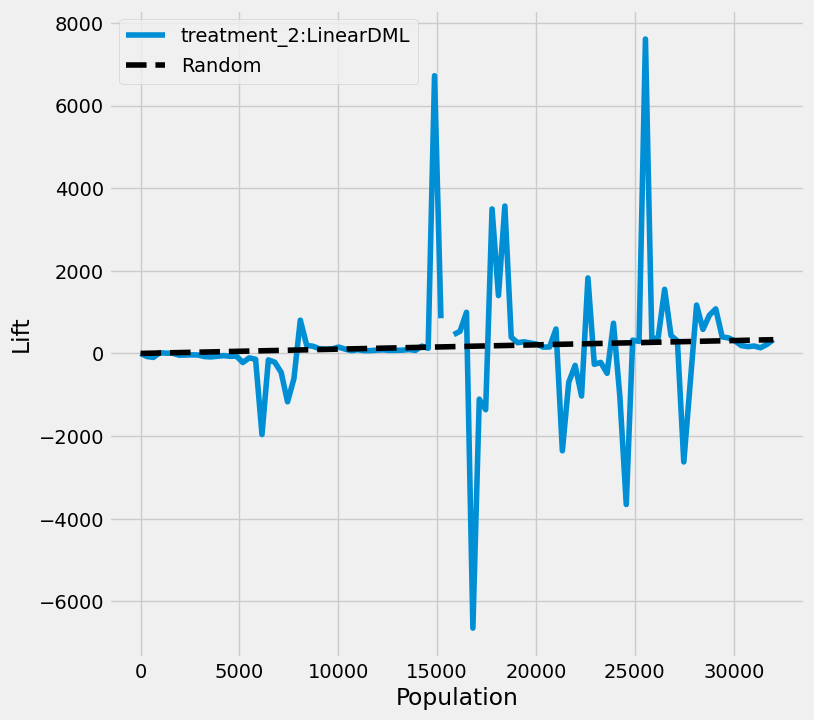

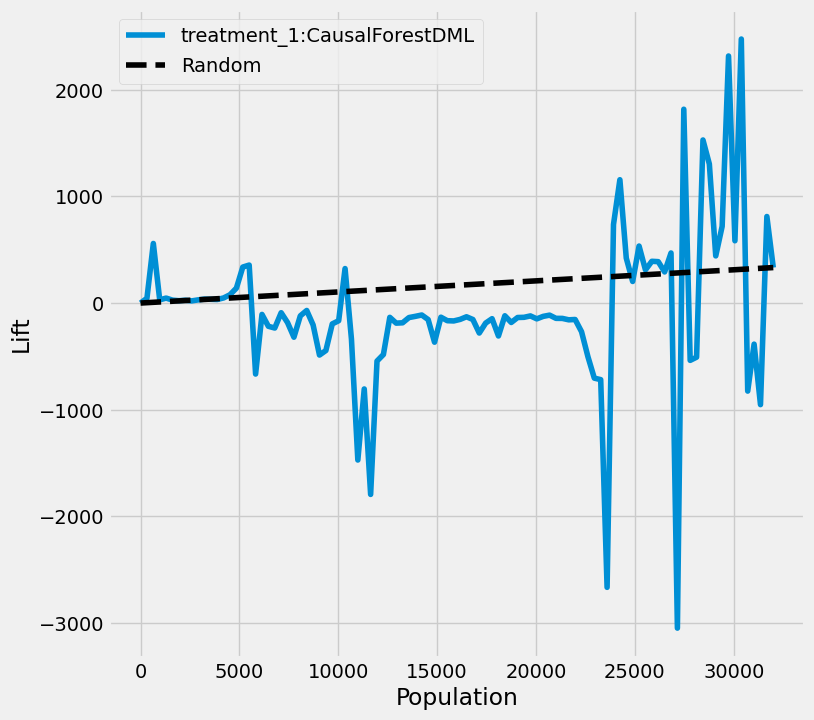

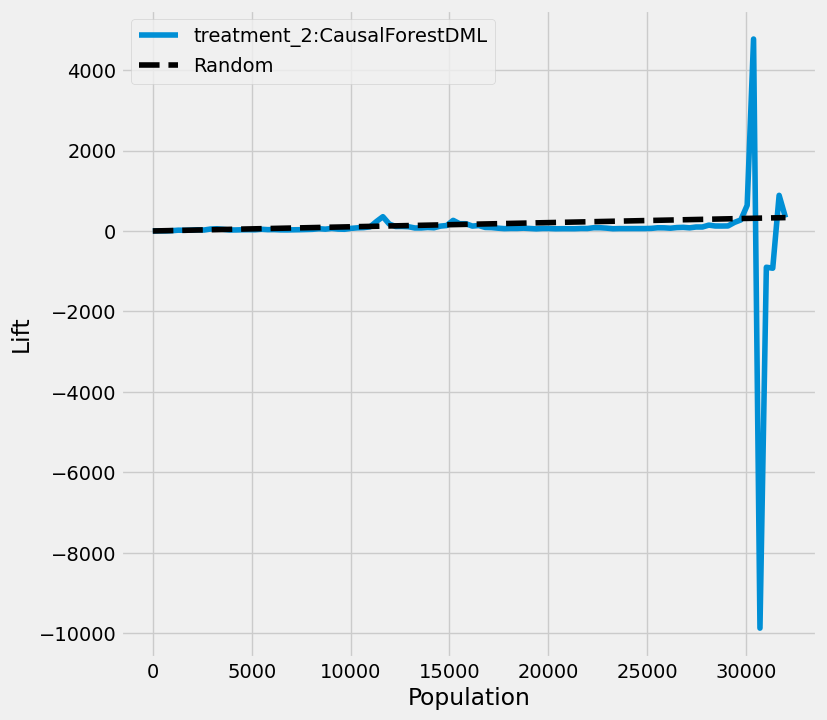

In [158]:
from causalml.metrics import plot_lift
for model in models.keys():
  for treatment in ['treatment_1', 'treatment_2']:
    effect_pred=effects_test[treatment][model]
    df_eval = pd.DataFrame({
    'is_treated': T_test,       # 治療組標籤
    'conversion': y_test,       # 實際轉化結果
    f'{treatment}:{model}': effect_pred.flatten() # 模型預測的 Uplift 分數
})
    plot_lift(df_eval, outcome_col='conversion', treatment_col='is_treated')

In [159]:
treatment='treatment_1'
model='SLearner'
effect_pred=effects_test[treatment][model]
df_eval = pd.DataFrame({
    'is_treated': T_test,       # 治療組標籤
    'conversion': y_test,       # 實際轉化結果
    f'{treatment}:{model}': effect_pred.flatten() # 模型預測的 Uplift 分數
})



In [160]:
uplift_by_decile_test = get_uplift_by_decile(
            uplifts=effects_test[treatment][model_name],
            t_true=T_test,
            t_pred=int(treatment.split('_')[-1]),
            y_true=y_test
        )

In [161]:
def get_cumlift_by_decile(uplifts, t_true, t_pred, y_true):

    # Encapsulate the data & sort according to uplifts
    all_data = pd.DataFrame(
        dict(
            uplifts=uplifts,
            y_true=y_true,
            t_true=t_true)
    ).query(f't_true==0 | t_true=={t_pred}').sort_values('uplifts')

    # Partition into deciles
    # Let pd.qcut assign labels automatically as integer indicators
    # This handles cases where `duplicates='drop'` results in fewer than `q` unique bins.
    all_data['deciles'] = pd.qcut(all_data['uplifts'], q=10, duplicates='drop', labels=False)
    # add by halmin
    all_data['y_true_cumsum']= all_data['y_true'].cumsum()
    # Get mean responses within deciles, unstack to separate treatments into columns
    ## TODO: seems mean () is contradict with cumsum
    ## max seems not correct, as the cumsum last one maynot be the max
    mean_decile_resp = all_data.groupby(['deciles', 't_true']).max().unstack(level='t_true')

    # Compute true decile uplift
    control_col = 0
    treatment_col = t_pred

    # Ensure both control and treatment columns exist after unstacking
    # Fill missing columns with 0 if a treatment/control group is not present in a decile
    if control_col not in mean_decile_resp['y_true_cumsum'].columns:
        mean_decile_resp['y_true_cumsum'][control_col] = 0
    if treatment_col not in mean_decile_resp['y_true_cumsum'].columns:
        mean_decile_resp['y_true_cumsum'][treatment_col] = 0

    # Calculate uplift: Treatment - Control
    true_uplift = mean_decile_resp['y_true_cumsum'][treatment_col] - mean_decile_resp['y_true_cumsum'][control_col]
    #true_uplift[::-1]
    return mean_decile_resp

In [162]:
uplifts=effects_test[treatment][model_name]
t_true=T_test
t_pred=int(treatment.split('_')[-1])
y_true=y_test

# Encapsulate the data & sort according to uplifts
all_data = pd.DataFrame(
    dict(
        uplifts=uplifts,
        y_true=y_true,
        t_true=t_true)
).query(f't_true==0 | t_true=={t_pred}').sort_values('uplifts')

# Partition into deciles
# Let pd.qcut assign labels automatically as integer indicators
# This handles cases where `duplicates='drop'` results in fewer than `q` unique bins.
all_data['deciles'] = pd.qcut(all_data['uplifts'], q=10, duplicates='drop', labels=False)
# add by halmin
all_data['y_true_cumsum']= all_data['y_true'].cumsum()
all_data['t_true_cumsum'] = all_data['t_true'].cumsum()
all_data['t_false_cumsum'] =(1- all_data['t_true']).cumsum()
# Get mean responses within deciles, unstack to separate treatments into columns
## TODO: seems mean () is contradict with cumsum
## max seems not correct, as the cumsum last one maynot be the max
mean_decile_resp = all_data.groupby(['deciles', 't_true']).max().unstack(level='t_true')

# Compute true decile uplift
control_col = 0
treatment_col = t_pred

# Ensure both control and treatment columns exist after unstacking
# Fill missing columns with 0 if a treatment/control group is not present in a decile
if control_col not in mean_decile_resp['y_true_cumsum'].columns:
    mean_decile_resp['y_true_cumsum'][control_col] = 0
if treatment_col not in mean_decile_resp['y_true_cumsum'].columns:
    mean_decile_resp['y_true_cumsum'][treatment_col] = 0

# Calculate uplift: Treatment - Control
true_uplift = mean_decile_resp['y_true_cumsum'][treatment_col] - mean_decile_resp['y_true_cumsum'][control_col]
#true_uplift[::-1]


In [163]:
cumlift_by_decile_test = get_cumlift_by_decile(
            uplifts=effects_test[treatment][model_name],
            t_true=T_test,
            t_pred=int(treatment.split('_')[-1]),
            y_true=y_test
        )

In [164]:
cumlift_by_decile_test

uplifts             y_true         y_true_cumsum          
t_true           0          1       0       1             0         1
deciles                                                              
0        -1.180513  -1.180513  227.54  414.08       2735.56   2735.56
1        -0.299272  -0.299664  209.68  182.91       4584.86   4584.86
2        -0.029373  -0.029387   95.63  499.00       5950.43   5950.43
3        -0.002371  -0.002371  220.96  395.24       7776.26   7776.26
4         0.017037   0.017037  444.92  298.33       9580.10   9580.10
5         0.119983   0.120026  397.29  173.02      11217.70  11217.70
6         0.370642   0.370455  444.33  230.46      13138.58  13138.58
7         0.899944   0.899706  170.39  146.20      14013.43  14013.43
8         2.201340   2.201642  499.00  309.08      15953.18  15953.18
9        40.015279  29.384365  167.45  499.00      19340.40  19340.40

In [165]:
from causalml.metrics import  get_cumgain,get_cumlift

In [166]:
get_cumlift(df_eval[(df_eval.is_treated==1) | (df_eval.is_treated==0)], outcome_col='conversion', treatment_col='is_treated')

,treatment_1:SLearner
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
21398,0.421696
21399,0.421761
21400,0.421826
21401,0.421892


In [167]:
causalml_cumlift=get_cumlift(df_eval[(df_eval.is_treated==1) | (df_eval.is_treated==0)], outcome_col='conversion', treatment_col='is_treated')

<Axes: >

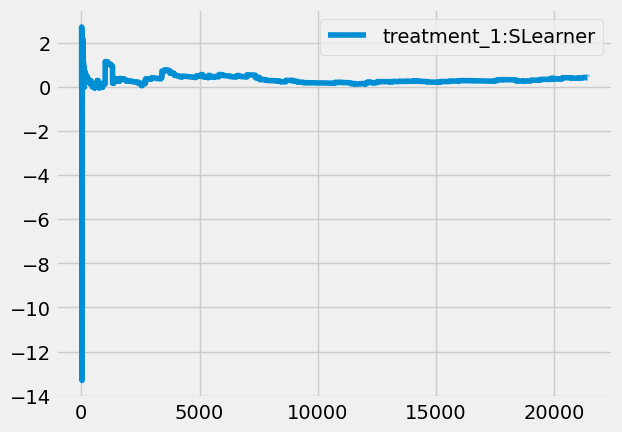

In [168]:
causalml_cumlift.plot()

In [169]:
causalml_cumgain=causalml_cumlift.mul(causalml_cumlift.index.values,axis=0)

In [170]:
causalml_cumgain_plotdf=causalml_cumgain.iloc[np.linspace(0, causalml_cumgain.index[-1], 100, endpoint=True).astype(int)]

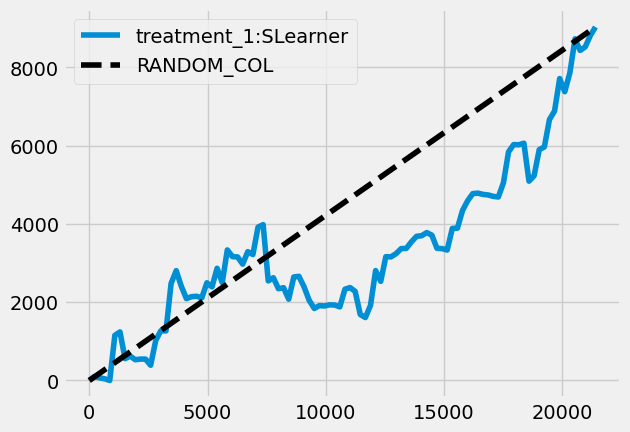

In [171]:
ax=causalml_cumgain_plotdf.plot()
chance_level_line_kw = {
            "label": "RANDOM_COL",
            "color": "k",
            "linestyle": "--",
        }
ax.plot([0, causalml_cumgain_plotdf.index[-1]], [0, causalml_cumgain_plotdf.iloc[-1, 0]], **chance_level_line_kw)
ax.legend()


In [172]:
causalml_cumlift.iloc[np.linspace(0, causalml_cumlift.index[-1], 100, endpoint=True).astype(int)]

,treatment_1:SLearner
0,0.000000
216,0.467763
432,0.157583
648,0.065579
864,-0.000242
...,...
20537,0.424979
20753,0.406273
20969,0.406427
21185,0.416038


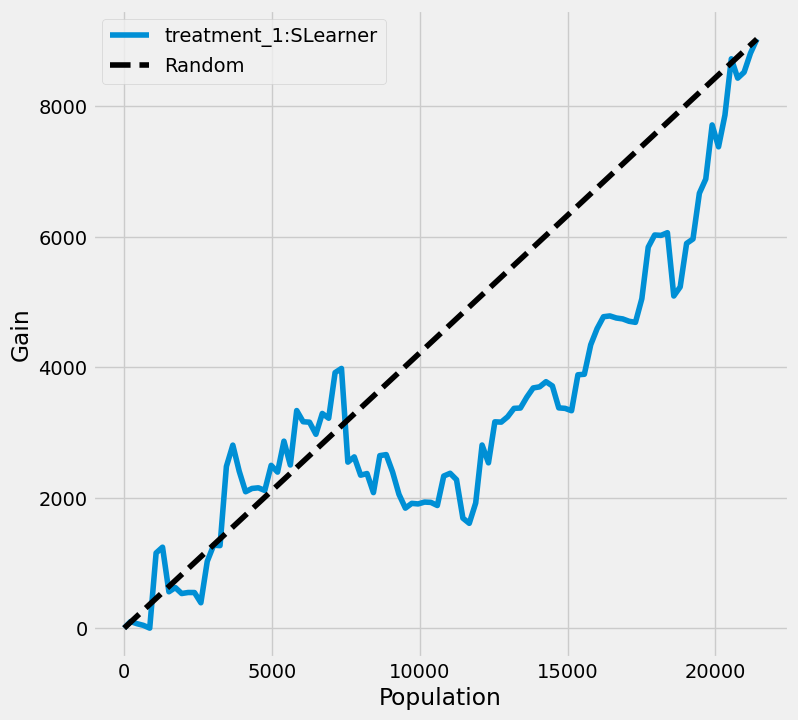

In [173]:
from causalml.metrics import plot_gain

plot_gain(df_eval[(df_eval.is_treated==1) | (df_eval.is_treated==0)], outcome_col='conversion', treatment_col='is_treated')

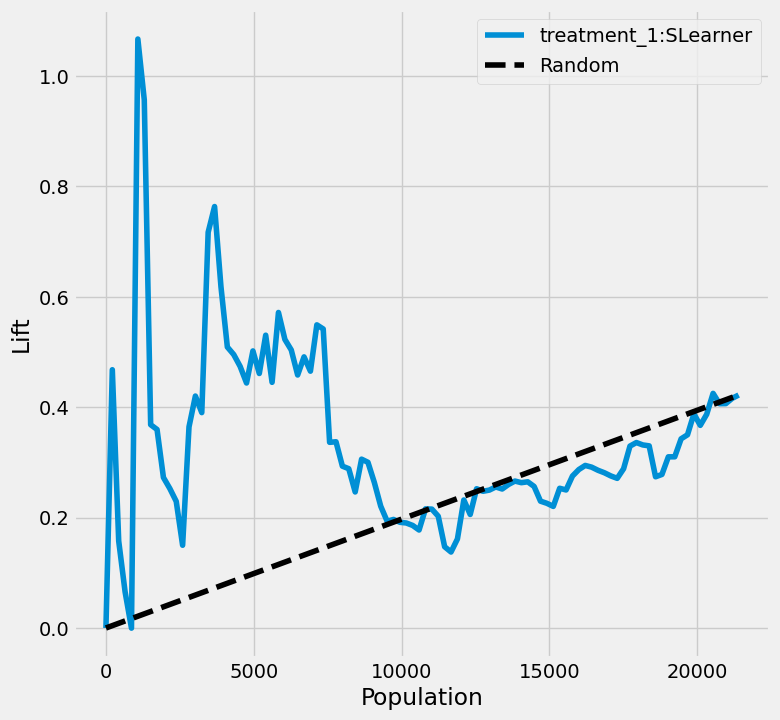

In [174]:
plot_lift(df_eval[(df_eval.is_treated==1) | (df_eval.is_treated==0)], outcome_col='conversion', treatment_col='is_treated')

In [175]:
treatment='treatment_1'
model='TLearner'
effect_pred=effects_test[treatment][model]
df_eval = pd.DataFrame({
    'is_treated': T_test,       # 治療組標籤
    'conversion': y_test,       # 實際轉化結果
    f'{treatment}:{model}': effect_pred.flatten() # 模型預測的 Uplift 分數
})

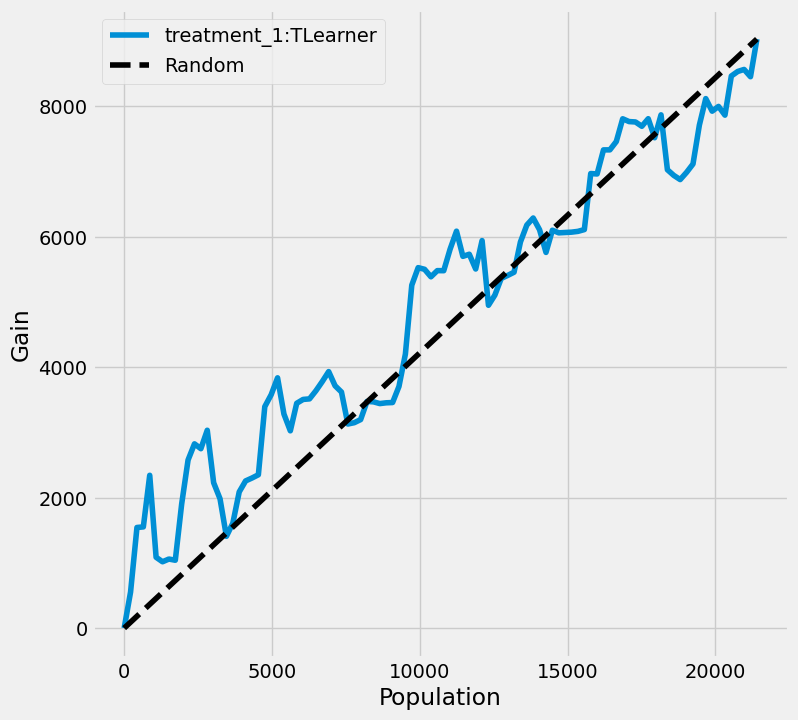

In [176]:
from causalml.metrics import plot_gain

plot_gain(df_eval[(df_eval.is_treated==1) | (df_eval.is_treated==0)], outcome_col='conversion', treatment_col='is_treated')

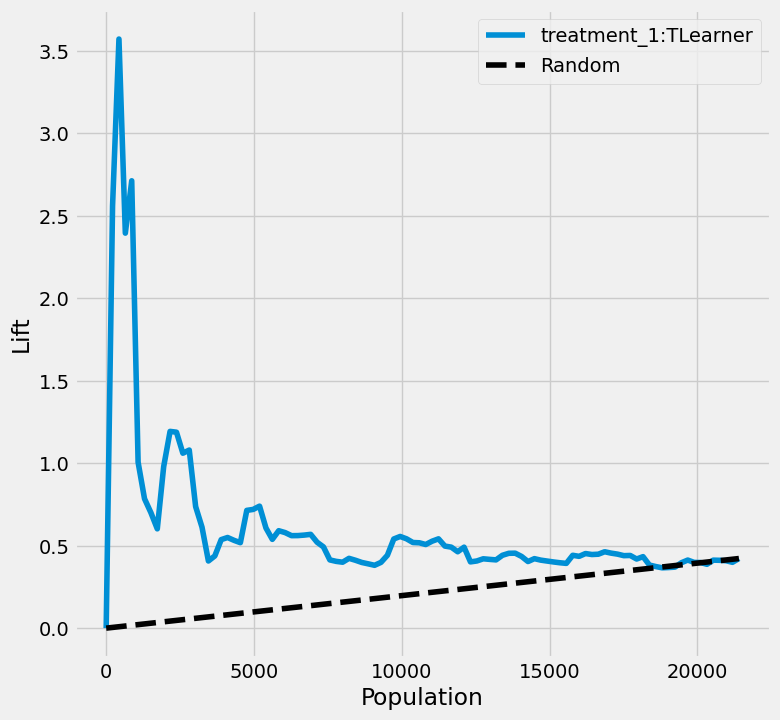

In [177]:
plot_lift(df_eval[(df_eval.is_treated==1) | (df_eval.is_treated==0)], outcome_col='conversion', treatment_col='is_treated')

#### Expected response

As introduced by [Zhao et al., 2017](https://arxiv.org/pdf/1705.08492.pdf)

Formula:

$$\Large Z = \sum_{t=0}^K \frac{1}{P(T=t)}y \mathbb{I}_{h(x)=t}\mathbb{I}_{T=t}$$

<br>


* $K$ is a number of treatment levels

* $\mathbb{I}$ is an indicator function

* $h(x)$ is the treatment recommended by the model (treatment leading to the highest uplift)

In [178]:
def get_effects_argmax(effects_arrays, return_matrix=False):
    """Returns argmax for each row of predicted effects for the arbitrary no. of treatments.

    :param effects_arrays: A list of arrays for K treatments, where K>=1 (without control null effects)
    :type effects_arrays: list of np.arrays

    :param return_matrix: Determines if the function returns a matrix of all effects
        (with added null effect for control)
    :type return_matrix: bool

    ...
    :return: A stacked matrix of all effects with added column for control effects (which is always 0)
    :rtype: np.array
    """

    n_rows = effects_arrays[0].shape[0]
    null_effect_array = np.zeros(n_rows)
    stacked = np.stack([null_effect_array] + effects_arrays).T

    if return_matrix:
        return np.argmax(stacked, axis=1), stacked

    return np.argmax(stacked, axis=1)


def get_expected_response(y_true, t_true, effects_argmax):
    """Computes the average expected response for an uplift model according to the formula
        proposed by:
        Zhao, Y., Fang, X., & Simchi-Levi, D. (2017). Uplift Modeling with Multiple Treatments and General Response Types.
        Proceedings of the 2017 SIAM International Conference on Data Mining, 588-596.
        Society for Industrial and Applied Mathematics.
    """

    proba_t = pd.Series(t_true).value_counts() / np.array(t_true).shape[0]
    treatments = proba_t.index.values

    z_vals = 0

    for treatment in treatments:
        h_indicator = effects_argmax == treatment
        t_indicator = t_true == treatment
        t_proba_local = proba_t[treatment]

        z_vals += (1/t_proba_local) * y_true * h_indicator * t_indicator

    return z_vals.mean()

In [179]:
# Compute expected response
print('Expecetd response on train:\n')
for model_name in models:
    effects_argmax = get_effects_argmax(
        [
            effects_train['treatment_1'][model_name],
            effects_train['treatment_2'][model_name]
        ]
    )

    expected_response = get_expected_response(
        y_true=y_train,
        t_true=T_train,
        effects_argmax=effects_argmax
    )

    print(f'{model_name}: {expected_response}')

print('\n' + '-'*30)

print('Expected response on test:\n')
for model_name in models:
    effects_argmax = get_effects_argmax(
        [
            effects_test['treatment_1'][model_name],
            effects_test['treatment_2'][model_name]
        ]
    )

    expected_response = get_expected_response(
        y_true=y_test,
        t_true=T_test,
        effects_argmax=effects_argmax
    )

    print(f'{model_name}: {expected_response}')

Expecetd response on train:

SLearner: 1.6682236169344227
TLearner: 2.4297331020074027
XLearner: 2.217021860698824
DRLearner: 2.1537189795364897
LinearDML: 1.3900407399860621
CausalForestDML: 2.6797132176797693

------------------------------
Expected response on test:

SLearner: 1.2177543815283354
TLearner: 1.4749894934756693
XLearner: 1.5138126687851445
DRLearner: 1.519351761106106
LinearDML: 1.6009636491351567
CausalForestDML: 1.3479622781585185


In [180]:
# Outcome in the whole dataset
hillstrom_clean.groupby('treatment')['spend'].mean()

,spend
treatment,
0,0.652789
1,1.077202
2,1.422617


#### Confidence intervals

In [181]:
models['LinearDML'].effect_interval(X=X_test, T0=0, T1=1)

(array([-1.7733113 , -1.19718069, -1.57226493, ...,  0.65425781,
        -0.24570221, -0.99721368]),
 array([0.42152277, 1.79645612, 0.18886628, ..., 2.48484701, 1.31859088,
        1.05311212]))

In [182]:
models['LinearDML'].effect_interval(X=X_test.iloc[0:1, :], T0=0, T1=1)

(array([-1.7733113]), array([0.42152277]))

In [183]:
# CIs (DML)
ints = np.stack(models['LinearDML'].effect_interval(X=X_test, T0=0, T1=1, alpha=.05)).T

# What % of effects contains zero?
(np.sign(ints[:, 0]) == np.sign(ints[:, 1])).sum() / ints.shape[0]

np.float64(0.15690625)

## plot_lift demo

ERROR:duecredit:Failed to import duecredit due to No module named 'duecredit'


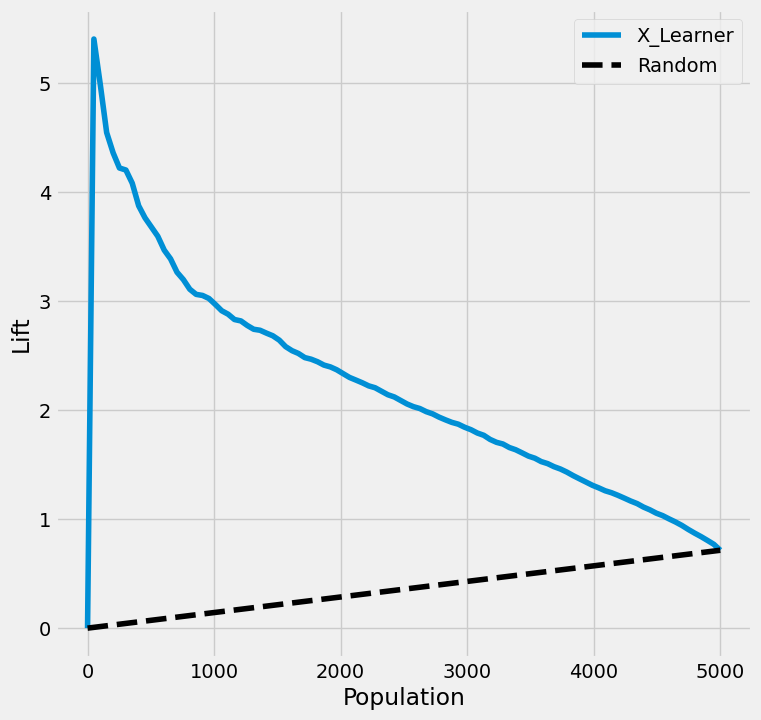

In [184]:
import pandas as pd
from causalml.dataset import synthetic_data
from causalml.inference.meta import BaseXRegressor
from causalml.metrics import plot_lift
from sklearn.ensemble import RandomForestRegressor

# 1. Generate synthetic data (mode=2 includes treatment effects)
y, X, w, tau, b, e = synthetic_data(mode=2, n=5000, p=10, sigma=1.0)
feature_names = [f'feature_{i}' in range(X.shape[1])]

# 2. Train a Meta-Learner (X-Learner) to estimate CATE
learner = BaseXRegressor(learner=RandomForestRegressor())
learner.fit(X, w, y)
cate_pred = learner.predict(X).flatten()

# 3. Prepare a DataFrame for plotting
# plot_lift requires a DataFrame with 'treatment', 'outcome', and model predictions
df = pd.DataFrame({'treatment': w, 'outcome': y, 'X_Learner': cate_pred})

# 4. Plot the Lift Curve
plot_lift(df, outcome_col='outcome', treatment_col='treatment', n=100, figsize=(8, 8))
